# Field Service Simulation - Core Module

This notebook implements request generation and admission, route planning, route execution, repair outcomes, carry-over, and the two dispatching policies described in the Project 2 problem statement.

## 1 - Imports, parameters, helper functions, and core simulation class

The constants below define the baseline system parameters from the problem description.

## Input Parameters

`MINUTES_PER_DAY` is the 480-minute working shift used for planning and execution checks. `MINUTES_PER_CALENDAR_DAY` is the 24-hour interval between the starts of consecutive working days.

In [ ]:
import simpy
import numpy as np

np.set_printoptions(precision=3)

# -----------------------------------------------------------------------------
# Simulation settings
# -----------------------------------------------------------------------------
MINUTES_PER_DAY = 480                  # length of the daily working shift
MINUTES_PER_CALENDAR_DAY = 24 * 60     # time between consecutive workday starts
PLANNING_SAFETY_MIN = 20              # safety allowance in every planning feasibility check
DAILY_TASK_LIMIT = 160                 # carryover has precedence; only new arrivals are admission-limited

# -----------------------------------------------------------------------------
# Service area
# -----------------------------------------------------------------------------
GRID_SIZE = 10                         # coordinates: 0, ..., 9
DEPOT = (5, 5)                         # baseline depot

# -----------------------------------------------------------------------------
# Travel-time model: fixed preparation time + triangular time per distance unit
# -----------------------------------------------------------------------------
TRAVEL_BASE_MIN = 5
TRAVEL_TRI_LOW = 5
TRAVEL_TRI_MODE = 7.5
TRAVEL_TRI_HIGH = 12
TRAVEL_MEAN_PER_UNIT = (TRAVEL_TRI_LOW + TRAVEL_TRI_MODE + TRAVEL_TRI_HIGH) / 3

# -----------------------------------------------------------------------------
# Demand
# -----------------------------------------------------------------------------
ARRIVALS_PER_DAY = 80
P_INSTALL = 0.60
P_REPAIR = 0.40

# -----------------------------------------------------------------------------
# Workforce
# -----------------------------------------------------------------------------
NUM_R1 = 3                              # Type R1 repair technicians
NUM_R2 = 3                              # Type R2 repair technicians
NUM_INSTALL = 3                         # dedicated installation technicians

# -----------------------------------------------------------------------------
# Service-time model: Gamma(shape alpha, scale theta)
# -----------------------------------------------------------------------------
INSTALL_GAMMA_SHAPE = 16
INSTALL_GAMMA_SCALE = 1.5
INSTALL_MEAN = INSTALL_GAMMA_SHAPE * INSTALL_GAMMA_SCALE
R1_REPAIR_GAMMA_SHAPE = 4
R1_REPAIR_GAMMA_SCALE = 5
R1_REPAIR_MEAN = R1_REPAIR_GAMMA_SHAPE * R1_REPAIR_GAMMA_SCALE
R2_REPAIR_GAMMA_SHAPE = 9
R2_REPAIR_GAMMA_SCALE = 5 / 3
R2_REPAIR_MEAN = R2_REPAIR_GAMMA_SHAPE * R2_REPAIR_GAMMA_SCALE
# -----------------------------------------------------------------------------
# Repair success
# -----------------------------------------------------------------------------
R1_SUCCESS_PROB = 0.90                  # first-attempt success probability for Type R1
# Type R2 repairs always succeed. Installations cannot fail.

# -----------------------------------------------------------------------------
# Priority scalar for dispatching
# -----------------------------------------------------------------------------
PRIORITY_SCALAR_INIT = {'installation': 0, 'repair': 1}
PRIORITY_SCALAR_MAX = 5



## Helper Functions

These functions implement the job representation, priority rule, Manhattan distance, and the expected and sampled travel and service times stated in the problem description.

In [ ]:
def make_job(job_id, day_created, location, request_type,
             carryover=False, second_attempt=False, waiting_days=0):
    """Create one request/job record used by the simulation.

    The original job identifier and creation day are retained when a job is
    carried over. ``second_attempt`` identifies failed Type R1 repairs that
    may subsequently be assigned only to a Type R2 technician.
    """
    return {
        'job_id': int(job_id),
        'day_created': int(day_created),
        'location': tuple(location),
        'request_type': request_type,
        'carryover': bool(carryover),
        'second_attempt': bool(second_attempt),
        'waiting_days': int(waiting_days),
    }


def priority_scalar(job):
    """Return the problem-defined priority, capped at 5.

    New installations start at 0, new repairs start at 1, and priority
    increases by one after each unresolved day.
    """
    init = PRIORITY_SCALAR_INIT.get(job['request_type'], 0)
    return min(init + job['waiting_days'], PRIORITY_SCALAR_MAX)


def manhattan(a, b):
    """Return the Manhattan distance between two grid locations."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def sample_travel_time(a, b, rng,
                       base=TRAVEL_BASE_MIN,
                       low=TRAVEL_TRI_LOW,
                       mode=TRAVEL_TRI_MODE,
                       high=TRAVEL_TRI_HIGH):
    """Sample actual travel time for one trip leg.

    Every leg includes the fixed preparation component. The stochastic time
    per grid-distance unit follows the triangular distribution specified in
    the problem description.
    """
    dist = manhattan(a, b)
    if dist == 0:
        return base
    return base + dist * rng.triangular(low, mode, high)


def expected_travel_time(a, b,
                         base=TRAVEL_BASE_MIN,
                         mean_per_unit=TRAVEL_MEAN_PER_UNIT):
    """Return expected trip-leg travel time used during planning and checks."""
    dist = manhattan(a, b)
    if dist == 0:
        return base
    return base + dist * mean_per_unit


def sample_service_time(tech_type, request_type, rng):
    """Sample actual service time for the given job-technician combination."""
    if request_type == 'installation':
        return rng.gamma(INSTALL_GAMMA_SHAPE, INSTALL_GAMMA_SCALE)
    if tech_type == 'R1':
        return rng.gamma(R1_REPAIR_GAMMA_SHAPE, R1_REPAIR_GAMMA_SCALE)
    if tech_type == 'R2':
        return rng.gamma(R2_REPAIR_GAMMA_SHAPE, R2_REPAIR_GAMMA_SCALE)
    raise ValueError('Dedicated installation technicians cannot perform repair jobs')


def expected_service_time(tech_type, request_type):
    """Return expected service time for planning and execution checks."""
    if request_type == 'installation':
        return INSTALL_MEAN
    if tech_type == 'R1':
        return R1_REPAIR_MEAN
    if tech_type == 'R2':
        return R2_REPAIR_MEAN
    raise ValueError('Dedicated installation technicians cannot perform repair jobs')

## Main Simulation Module

`FieldServiceSim` first creates the daily requests, admits carry-over jobs before new requests, constructs routes according to the selected policy, and then executes all technician routes concurrently. Planning uses expected times; execution uses sampled travel and service times.

In [ ]:
class FieldServiceSim:
    """Simulate the field-service process defined in the problem statement.

    The class covers request generation and admission, both dispatching
    policies, route execution, repair outcomes, and carry-over.

    Consecutive workdays start 24 hours apart in simulation time. Each workday
    still has the problem-defined 480-minute shift. After every technician has
    returned to the depot, the environment advances through the remaining
    inactive time until the start of the next calendar day.
    """

    def __init__(self, policy, seed, *,
                 sim_days,
                 arrivals_per_day,
                 p_repair,
                 p_install,
                 num_R1,
                 num_R2,
                 num_install,
                 R1_success,
                 depot,
                 travel_base,
                 travel_low,
                 travel_mode,
                 travel_high,
                 arrival_seed=None):
        """Initialize one simulation configuration and its random streams.

        ``seed`` controls travel times, service times, and repair outcomes.
        ``arrival_seed`` optionally controls request generation separately.
        The remaining arguments define the horizon, demand, workforce, depot,
        dispatching policy, and travel-time distribution.
        """

        # Validate the dispatching-policy name before any state is created.
        if policy not in {'priority', 'nearest'}:
            raise ValueError("policy must be either 'priority' or 'nearest'")

        # The simulation horizon must contain at least one working day.
        if int(sim_days) < 1:
            raise ValueError('sim_days must be at least 1')

        # A Poisson arrival rate cannot be negative.
        if arrivals_per_day < 0:
            raise ValueError('arrivals_per_day must be non-negative')

        # Request-type probabilities must be valid and form a full distribution.
        if not (0 <= p_repair <= 1 and 0 <= p_install <= 1):
            raise ValueError('request-type probabilities must lie in [0, 1]')
        if abs(p_repair + p_install - 1.0) > 1e-9:
            raise ValueError('p_repair and p_install must sum to 1')

        # Every technician-group size must be non-negative.
        if any(int(n) < 0 for n in (num_R1, num_R2, num_install)):
            raise ValueError('technician counts must be non-negative')

        # The Type R1 first-attempt success probability must be valid.
        if not 0 <= R1_success <= 1:
            raise ValueError('R1_success must lie in [0, 1]')

        # Validate the ordering of the triangular travel-time parameters.
        if not (0 <= travel_low <= travel_mode <= travel_high):
            raise ValueError('travel parameters must satisfy 0 <= low <= mode <= high')

        # The fixed preparation component of a trip cannot be negative.
        if travel_base < 0:
            raise ValueError('travel_base must be non-negative')

        # Convert the depot to an immutable coordinate pair and verify that it
        # lies on the 10 x 10 service grid.
        depot = tuple(depot)
        if len(depot) != 2 or any(not 0 <= int(c) < GRID_SIZE for c in depot):
            raise ValueError(f'depot coordinates must lie in 0, ..., {GRID_SIZE - 1}')

        # Store the general simulation, demand, workforce, and depot settings.
        self.policy = policy
        self.sim_days = int(sim_days)
        self.arrivals_per_day = float(arrivals_per_day)
        self.p_repair = float(p_repair)
        self.p_install = float(p_install)
        self.num_R1 = int(num_R1)
        self.num_R2 = int(num_R2)
        self.num_install = int(num_install)
        self.R1_success = float(R1_success)
        self.depot = depot

        # Store the travel distribution and calculate its expected value per
        # grid-distance unit for route planning and execution checks.
        self.travel_base = float(travel_base)
        self.travel_low = float(travel_low)
        self.travel_mode = float(travel_mode)
        self.travel_high = float(travel_high)
        self.travel_mean_per_unit = (self.travel_low + self.travel_mode + self.travel_high) / 3
        # Repeated expected-time calculations for the same trip leg are cached.
        self._expected_travel_cache = {}

        # Use separate random-number streams for request generation and for
        # route execution. If no arrival seed is given, seed also defines demand.
        if seed is None:
            seed = np.random.randint(1, 1001)
            arrival_rng = np.random.default_rng(seed if arrival_seed is None else arrival_seed)
            self.rng = np.random.default_rng(seed + 1)
        else:
            arrival_rng = np.random.default_rng(seed if arrival_seed is None else arrival_seed)
            self.rng = np.random.default_rng(seed + 1)

        # SimPy's environment stores and advances the simulation clock.
        self.env = simpy.Environment()
        # Job identifiers increase across the full simulation horizon.
        self.job_counter = 0

        # These structures connect each technician identifier to its type and
        # to the SimPy resource representing that technician's availability.
        self.tech_ids = []
        self.tech_types = {}
        self.tech_resources = {}

        # Create Type R1 technicians in identifier order: R1-1, R1-2, ...
        for i in range(self.num_R1):
            tid = f'R1-{i + 1}'
            # Add the identifier to the common technician sequence.
            self.tech_ids.append(tid)
            # Store the technician type for eligibility and service-time rules.
            self.tech_types[tid] = 'R1'
            # Capacity one prevents simultaneous activities by one technician.
            self.tech_resources[tid] = simpy.Resource(self.env, capacity=1)

        # Create Type R2 technicians in identifier order: R2-1, R2-2, ...
        for i in range(self.num_R2):
            tid = f'R2-{i + 1}'
            self.tech_ids.append(tid)
            self.tech_types[tid] = 'R2'
            self.tech_resources[tid] = simpy.Resource(self.env, capacity=1)

        # Create dedicated installation technicians: I-1, I-2, ...
        for i in range(self.num_install):
            tid = f'I-{i + 1}'
            self.tech_ids.append(tid)
            self.tech_types[tid] = 'install'
            self.tech_resources[tid] = simpy.Resource(self.env, capacity=1)

        # Requests are generated before the run so their identifiers establish
        # the deterministic order used for admission and policy tie-breaking.
        self._pregenerated_arrivals = {}
        # Generate one ordered request list for every simulated day.
        for d in range(1, self.sim_days + 1):
            # Sample the day's request count from the Poisson distribution.
            n = int(arrival_rng.poisson(self.arrivals_per_day))
            # Collect requests in generation and job-identifier order.
            jobs = []
            # Generate the type and location of each request independently.
            for _ in range(n):
                # A request is a repair with probability p_repair; otherwise
                # it is an installation because the two probabilities sum to 1.
                rtype = 'repair' if arrival_rng.random() < self.p_repair else 'installation'
                # Both coordinates are sampled uniformly from 0, ..., 9.
                loc = (int(arrival_rng.integers(0, GRID_SIZE)),
                       int(arrival_rng.integers(0, GRID_SIZE)))
                # Assign the next unique identifier and create the request.
                self.job_counter += 1
                jobs.append(make_job(self.job_counter, d, loc, rtype))
            # Save the complete ordered request list for day d.
            self._pregenerated_arrivals[d] = jobs

        # Initialize state that changes as run() advances through the days.
        self.day = 0
        self.day_start = 0.0
        self.day_end = 0.0
        self.carryover = []

    def expected_travel_time(self, a, b):
        """Return and cache expected travel time for trip leg ``a`` to ``b``."""
        # Coordinates define the cache key. Travel parameters are constant for
        # the lifetime of this simulation object.
        key = (a, b)
        # Calculate a value only the first time this trip leg is requested.
        if key not in self._expected_travel_cache:
            self._expected_travel_cache[key] = expected_travel_time(
                a, b, self.travel_base, self.travel_mean_per_unit
            )
        # Return either the newly calculated value or the cached value.
        return self._expected_travel_cache[key]

    def sample_travel_time(self, a, b):
        """Sample actual travel time using this simulation's random stream."""
        # Forward the configured fixed and triangular parameters to the helper.
        return sample_travel_time(a, b, self.rng, self.travel_base,
                                  self.travel_low, self.travel_mode, self.travel_high)

    def _generate_daily_arrivals(self):
        """Return copies of the requests generated for the current day."""
        # Copies prevent later carry-over changes from modifying the original
        # pregenerated request list.
        return [dict(j) for j in self._pregenerated_arrivals[self.day]]

    def _limit_daily_arrivals(self, carryover, new_jobs):
        """Apply the 160-task daily admission limit to new arrivals.

        Carry-over jobs always have precedence and are never discarded. If the
        carry-over count is at least the limit, no new request is admitted.
        The admitted new-job list is truncated to the remaining capacity, so the
        daily active pool is limited to DAILY_TASK_LIMIT by construction.
        """
        # Carry-over jobs occupy the active pool before new requests enter it.
        available_slots = max(0, DAILY_TASK_LIMIT - len(carryover))
        # New requests are already ordered by their unique job identifiers.
        accepted = new_jobs[:available_slots]
        # Requests after the capacity cut do not enter planning or carry-over.
        dropped = new_jobs[available_slots:]
        return accepted, dropped

    def _eligible(self, tech_id, job):
        """Apply technician eligibility rules from the problem description."""
        # Read the technician group once for the checks below.
        ttype = self.tech_types[tech_id]
        # Installations may be performed by every technician group, so only
        # repair requests require additional eligibility restrictions.
        if job['request_type'] == 'repair':
            # Dedicated installation technicians never perform repairs.
            if ttype == 'install':
                return False
            # A failed first attempt becomes an R2-only second attempt.
            if job['second_attempt'] and ttype != 'R2':
                return False
        # No restriction above excluded this technician-job combination.
        return True

    def _repair_technicians(self):
        """Return R2 technicians first, followed by R1 technicians."""
        # Dedicated installation technicians are excluded from this phase.
        # The tuple sort key first orders technician type and then identifier.
        return sorted(
            [tid for tid in self.tech_ids if self.tech_types[tid] != 'install'],
            key=lambda t: (0 if self.tech_types[t] == 'R2' else 1, t)
        )

    def _planning_times(self, tech_id, current_location, job):
        """Return expected travel, service, and return times for one assignment."""
        travel_to_job = self.expected_travel_time(current_location, job['location'])
        service_time = expected_service_time(
            self.tech_types[tech_id], job['request_type']
        )
        return_to_depot = self.expected_travel_time(job['location'], self.depot)
        return travel_to_job, service_time, return_to_depot

    def _is_planning_feasible(self, tech_id, current_location, remaining_time, job):
        """Check the planning rule for one technician-job combination."""
        travel_to_job, service_time, return_to_depot = self._planning_times(
            tech_id, current_location, job
        )
        required_time = (
            travel_to_job
            + service_time
            + return_to_depot
            + PLANNING_SAFETY_MIN
        )
        return required_time <= remaining_time

    def _installation_candidates(self, pool, current_location):
        """Return installation jobs ordered by distance and then job ID."""
        ranked_jobs = []
        for job in pool:
            if job['request_type'] == 'installation':
                distance = self.expected_travel_time(current_location, job['location'])
                ranked_jobs.append((distance, job['job_id'], job))
        ranked_jobs.sort(key=lambda item: (item[0], item[1]))
        return [item[2] for item in ranked_jobs]

    def _select_priority_job(self, pool, repair_techs, tech_pos):
        """Select the next job according to the priority-policy job ranking."""
        highest_priority = max(priority_scalar(job) for job in pool)
        ranked_jobs = []

        for job in pool:
            if priority_scalar(job) != highest_priority:
                continue

            eligible_techs = [
                tid for tid in repair_techs if self._eligible(tid, job)
            ]
            if eligible_techs:
                nearest_distance = min(
                    self.expected_travel_time(tech_pos[tid], job['location'])
                    for tid in eligible_techs
                )
            else:
                nearest_distance = float('inf')

            ranked_jobs.append((nearest_distance, job['job_id'], job))

        ranked_jobs.sort(key=lambda item: (item[0], item[1]))
        return ranked_jobs[0][2]

    def _priority_technicians(self, job, repair_techs, tech_pos):
        """Return eligible technicians in the priority-policy search order."""
        # Store one sortable entry for every technician who may perform this job.
        ranked_techs = []
        # Check all Type R2 and Type R1 technicians considered in phase 2.
        for tid in repair_techs:
            # Exclude technicians who cannot perform the request. For example,
            # second-attempt repairs can be performed only by Type R2.
            if not self._eligible(tid, job):
                continue

            # Type R2 receives rank 0 and Type R1 receives rank 1. Therefore,
            # every eligible R2 technician is considered before every R1.
            type_order = 0 if self.tech_types[tid] == 'R2' else 1
            # Within the same technician type, rank by expected travel from the
            # technician's current planned location to the selected job.
            distance = self.expected_travel_time(tech_pos[tid], job['location'])
            # The technician identifier is the final deterministic tie-breaker.
            ranked_techs.append((type_order, distance, tid))

        # Tuple sorting applies type, distance, and technician-ID order in sequence.
        ranked_techs.sort()
        # Remove the ranking values and return only the ordered technician IDs.
        return [item[2] for item in ranked_techs]

    def _nearest_candidates(self, pool, tech_id, current_location):
        """Return eligible jobs in the nearest-policy ranking order."""
        # Store each eligible job together with its three ranking values.
        ranked_jobs = []
        # Examine every unassigned job still available in the shared pool.
        for job in pool:
            # Remove jobs that this technician cannot perform. Dedicated repair
            # rules include the Type R2 requirement for second attempts.
            if not self._eligible(tech_id, job):
                continue

            # Distance from the technician's current planned location is the
            # primary ranking criterion of the nearest policy.
            distance = self.expected_travel_time(current_location, job['location'])
            # Store negative priority because Python sorts smaller values first;
            # this makes a larger job priority appear before a smaller priority.
            ranked_jobs.append((
                distance,
                -priority_scalar(job),
                # Job identifier is the final deterministic tie-breaker.
                job['job_id'],
                # Keep the complete job record so it can be returned after sorting.
                job,
            ))

        # Sort first by distance, then by higher priority, and finally by job ID.
        ranked_jobs.sort(key=lambda item: (item[0], item[1], item[2]))
        # Remove the ranking values and return the jobs in assignment-check order.
        return [item[3] for item in ranked_jobs]

    def _build_day_plan(self, pending_jobs):
        """Construct all technician routes using expected times.

        The common first phase fills dedicated installation-technician routes.
        The remaining jobs are then assigned using either the job-first priority
        policy or the technician-first nearest policy. Jobs left in the returned
        pool are carried over to the next day.
        """
        # Create one initially empty planned route for every technician.
        plan = {tid: [] for tid in self.tech_ids}
        # At the beginning of planning, every technician has the complete
        # 480-minute shift available.
        remaining_time = {tid: MINUTES_PER_DAY for tid in self.tech_ids}
        # Each technician's planned route starts at the central depot.
        tech_pos = {tid: self.depot for tid in self.tech_ids}
        # Copy the pending jobs because assigned jobs are removed from this pool.
        pool = list(pending_jobs)

        # ------------------------------------------------------------------
        # Common phase: dedicated installation technicians
        # ------------------------------------------------------------------
        # Select the dedicated installation technicians in identifier order.
        install_techs = [tid for tid in self.tech_ids if self.tech_types[tid] == 'install']
        # Construct the complete route of one installation technician before
        # continuing with the next installation technician.
        for tid in install_techs:
            # Continue adding installations until no further job can be assigned.
            while True:
                # Rank the remaining installation jobs by distance from this
                # technician's current planned location, followed by job ID.
                candidates = self._installation_candidates(pool, tech_pos[tid])
                # Stop this route when no installation job remains.
                if not candidates:
                    break

                # The flag remains False if all ranked candidates are infeasible.
                assigned = False
                # Check the ranked jobs and assign the first feasible one.
                for job in candidates:
                    # Feasibility includes expected travel to the job, expected
                    # service, expected return travel, and the safety allowance.
                    if self._is_planning_feasible(
                        tid, tech_pos[tid], remaining_time[tid], job
                    ):
                        # Obtain the expected travel and service time that will
                        # be deducted after accepting this job.
                        travel_to_job, service_time, _ = self._planning_times(
                            tid, tech_pos[tid], job
                        )
                        # Append the job to this technician's planned route.
                        plan[tid].append(job)
                        # Remove the assigned job so no other technician receives it.
                        pool.remove(job)
                        # Return travel and the safety allowance remain reserved
                        # through later feasibility checks and are not deducted here.
                        remaining_time[tid] -= travel_to_job + service_time
                        # Future distances for this route start from this customer.
                        tech_pos[tid] = job['location']
                        assigned = True
                        # Add only one job in this while-loop iteration, then
                        # rank the remaining jobs again from the new location.
                        break

                # If none of the remaining installations is feasible, the
                # current installation technician's route is complete.
                if not assigned:
                    break

        # The second planning phase uses only R2 and R1 technicians. The returned
        # order places all R2 technicians before all R1 technicians.
        repair_techs = self._repair_technicians()

        # ------------------------------------------------------------------
        # Priority policy: select a job first, then search for a technician
        # ------------------------------------------------------------------
        if self.policy == 'priority':
            # Collect selected jobs that no eligible technician can accept.
            unassigned = []
            # Select and process one job at a time until the pool is empty.
            while pool:
                # Select the highest-priority job. Within the same priority,
                # rank by distance to the nearest eligible technician and job ID.
                job = self._select_priority_job(pool, repair_techs, tech_pos)
                # Remove the selected job before attempting its assignment. It
                # will enter either a technician route or the unassigned list.
                pool.remove(job)

                # Rank eligible technicians for this job: R2 before R1, then
                # distance from the current planned location, then technician ID.
                placed = False
                ordered_techs = self._priority_technicians(
                    job, repair_techs, tech_pos
                )
                # Assign the selected job to the first feasible technician in
                # the required technician order.
                for tid in ordered_techs:
                    if self._is_planning_feasible(
                        tid, tech_pos[tid], remaining_time[tid], job
                    ):
                        # Calculate the expected travel and service time consumed
                        # by adding this job to the selected route.
                        travel_to_job, service_time, _ = self._planning_times(
                            tid, tech_pos[tid], job
                        )
                        # Update the technician's route and planned route state.
                        plan[tid].append(job)
                        remaining_time[tid] -= travel_to_job + service_time
                        tech_pos[tid] = job['location']
                        placed = True
                        # The job has been assigned, so no later technician is checked.
                        break

                # A job that is infeasible for every eligible technician remains
                # unassigned for this day.
                if not placed:
                    unassigned.append(job)

            # Return all planned routes and the jobs not assigned by this policy.
            return plan, unassigned

        # ------------------------------------------------------------------
        # Nearest policy: complete one technician route at a time
        # ------------------------------------------------------------------
        elif self.policy == 'nearest':
            # Complete each R2 route first and then each R1 route. One route is
            # completed before planning begins for the next technician.
            for tid in repair_techs:
                # Continue adding jobs until this technician has no feasible job.
                while True:
                    # Rank this technician's eligible jobs by distance, followed
                    # by higher priority and then job ID.
                    candidates = self._nearest_candidates(
                        pool, tid, tech_pos[tid]
                    )
                    # End this route when no eligible job remains in the pool.
                    if not candidates:
                        break

                    # Search the ranked list for the first feasible job.
                    assigned = False
                    for job in candidates:
                        if self._is_planning_feasible(
                            tid, tech_pos[tid], remaining_time[tid], job
                        ):
                            # Obtain the expected time consumed by this assignment.
                            travel_to_job, service_time, _ = self._planning_times(
                                tid, tech_pos[tid], job
                            )
                            # Append the job, remove it from the shared pool, and
                            # update the route's remaining time and location.
                            plan[tid].append(job)
                            pool.remove(job)
                            remaining_time[tid] -= travel_to_job + service_time
                            tech_pos[tid] = job['location']
                            assigned = True
                            # Re-rank the pool from the newly planned location.
                            break

                    # If every eligible job is infeasible, this technician's
                    # route is complete and planning moves to the next technician.
                    if not assigned:
                        break

            # Jobs still in the pool were not assigned by the nearest policy.
            return plan, pool

    def _run_tech_route(self, tech_id, route):
        """Execute one technician's planned route with sampled times.

        Before each planned job, feasibility is checked from the technician's
        actual current location using expected travel, service, and return time.
        If a job cannot be attempted, it is added to the next day's carry-over.
        The route does not stop immediately: every later assigned job is checked in route
        order because a later location may still be feasible. After all remaining
        jobs have been checked, the technician returns from the last attempted
        job location to the depot using sampled travel time.
        """
        # Read this technician's type for service-time and repair-outcome rules.
        ttype = self.tech_types[tech_id]
        # Retrieve the capacity-one resource representing this technician.
        resource = self.tech_resources[tech_id]
        # Every technician begins the route at the central depot.
        pos = self.depot

        # Follow the planned job sequence. A non-attempted job is skipped, but
        # every later job in the route is still checked in sequence.
        for job in route:
            # Actual elapsed working time includes sampled travel and service.
            elapsed = self.env.now - self.day_start
            # The execution feasibility check uses the remaining 480-minute shift.
            remaining = MINUTES_PER_DAY - elapsed
            # Expected travel is measured from the last actually attempted job,
            # or from the depot if no job has yet been attempted.
            t_to_exp = self.expected_travel_time(pos, job['location'])
            # Expected service depends on both technician type and request type.
            t_svc_exp = expected_service_time(ttype, job['request_type'])
            # Reserve enough expected time to return from this job to the depot.
            t_back_exp = self.expected_travel_time(job['location'], self.depot)

            # The execution check does not use the 20-minute planning allowance.
            # A skipped job does not change the technician's actual position.
            if t_to_exp + t_svc_exp + t_back_exp > remaining:
                # Store the original job so run() can recreate it as carry-over
                # with one additional unresolved day.
                self._day_not_attempted.append(job)
                # Keep the same actual position and check the next planned job.
                continue

            # Each technician has one route process, so the resource only models
            # that the technician can execute one activity at a time.
            req = resource.request()
            # Wait until the technician resource is available.
            yield req

            # Sample and execute the trip from the actual current position.
            t_travel = self.sample_travel_time(pos, job['location'])
            yield self.env.timeout(t_travel)

            # Sample and execute service at the customer location.
            t_svc = sample_service_time(ttype, job['request_type'], self.rng)
            yield self.env.timeout(t_svc)

            # Installations, R2 repairs, and second-attempt repairs complete.
            # Only a first-attempt R1 repair can fail.
            result = 'completed'
            if job['request_type'] == 'repair' and ttype == 'R1' and not job['second_attempt']:
                # Success occurs when the random draw is below R1_success.
                if self.rng.random() >= self.R1_success:
                    result = 'failed_first_attempt'

            # Service occurred at this customer, regardless of repair success,
            # so this becomes the technician's actual current position.
            pos = job['location']

            if result == 'failed_first_attempt':
                # A failed Type R1 repair becomes a second-attempt repair for
                # the next day and can then be assigned only to Type R2.
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    'repair', carryover=True, second_attempt=True,
                    waiting_days=job['waiting_days'] + 1
                ))

            # Release the technician after this job's travel and service finish.
            resource.release(req)

        # If no job was attempted, pos is already the depot and no trip occurs.
        # Otherwise this is the stochastic return leg from the last attempted job.
        if pos != self.depot:
            # Sample the final trip leg from the last attempted job to the depot.
            t_return = self.sample_travel_time(pos, self.depot)
            yield self.env.timeout(t_return)

    def run(self):
        """Run all simulated days and return the final carry-over list.

        The environment first waits for every technician route to finish and
        return to the depot. It then advances through the inactive remainder of
        the 24-hour calendar day before the next day's requests are processed.
        """
        # Simulate working days in chronological order.
        for day in range(1, self.sim_days + 1):
            # Expose the current day to arrival generation and other methods.
            self.day = day
            # Collect planned jobs that fail the execution feasibility check.
            self._day_not_attempted = []

            # Because the preceding iteration advances to the next calendar day,
            # consecutive day starts are normally exactly 1,440 minutes apart.
            # Record the calendar time at which this working day begins.
            self.day_start = self.env.now
            # day_end marks the nominal end of the 480-minute working shift.
            self.day_end = self.day_start + MINUTES_PER_DAY
            # The following working day begins 24 hours after this one.
            next_day_start = self.day_start + MINUTES_PER_CALENDAR_DAY

            # Save the unresolved jobs entering from the preceding day.
            prev_carry = self.carryover
            # Rebuild carry-over from this day's failures and unresolved jobs.
            self.carryover = []
            # Retrieve this day's pregenerated requests in job-ID order.
            generated_jobs = self._generate_daily_arrivals()
            # Admit carry-over first and then as many new requests as capacity allows.
            accepted_jobs, _ = self._limit_daily_arrivals(
                prev_carry, generated_jobs
            )
            # Only carry-over and accepted new requests enter route planning.
            pool = list(prev_carry) + list(accepted_jobs)

            # Requests beyond the active-pool capacity do not enter planning
            # or carry-over.
            plan, unassigned = self._build_day_plan(pool)

            # Start one concurrent SimPy process for every non-empty route.
            route_events = []
            for tid in self.tech_ids:
                # A technician with an empty route remains at the depot.
                if plan[tid]:
                    # Store the process event so all routes can be awaited together.
                    route_events.append(
                        self.env.process(self._run_tech_route(tid, plan[tid]))
                    )

            # Complete every started route, including its sampled return trip.
            if route_events:
                self.env.run(until=self.env.all_of(route_events))

            # Recreate every non-attempted job as next-day carry-over.
            for job in self._day_not_attempted:
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    job['request_type'], carryover=True,
                    second_attempt=job['second_attempt'],
                    waiting_days=job['waiting_days'] + 1
                ))

            # Recreate every job left unassigned during planning as carry-over.
            for job in unassigned:
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    job['request_type'], carryover=True,
                    second_attempt=job['second_attempt'],
                    waiting_days=job['waiting_days'] + 1
                ))

            # Advance through the non-working part of the calendar day. Actual
            # sampled durations may produce overtime beyond 480 minutes. In the
            # extremely unlikely case that a route exceeds 24 hours, no negative
            # waiting time is added and the following day starts when it finishes.
            if self.env.now < next_day_start:
                # Move the clock to the exact start of the following calendar day.
                self.env.run(until=next_day_start)

        # Return the unresolved jobs remaining after the final simulated day.
        return self.carryover



## Smoke Test

This cell creates and runs a three-day simulation for each dispatching policy.

In [18]:
# Run both dispatching policies for three days to verify the core module.
for policy in ('priority', 'nearest'):
    smoke_sim = FieldServiceSim(
        policy=policy,
        seed=None,
        sim_days=30,
        arrivals_per_day=ARRIVALS_PER_DAY,
        p_repair=P_REPAIR,
        p_install=P_INSTALL,
        num_R1=NUM_R1,
        num_R2=NUM_R2,
        num_install=NUM_INSTALL,
        R1_success=R1_SUCCESS_PROB,
        depot=DEPOT,
        travel_base=TRAVEL_BASE_MIN,
        travel_low=TRAVEL_TRI_LOW,
        travel_mode=TRAVEL_TRI_MODE,
        travel_high=TRAVEL_TRI_HIGH,
    )
    remaining_jobs = smoke_sim.run()
    print(f"Environment time after {policy} simulation: {smoke_sim.env.now:.2f} minutes corresponding to {smoke_sim.day} days simulated")
    print(f"Total jobs processed: {smoke_sim.job_counter}, Total carry-over jobs: {len(remaining_jobs)}")

Environment time after priority simulation: 43200.00 minutes corresponding to 30 days simulated
Total jobs processed: 2417, Total carry-over jobs: 18
Environment time after nearest simulation: 43200.00 minutes corresponding to 30 days simulated
Total jobs processed: 2308, Total carry-over jobs: 0


## From here: student code

In [19]:
# NEW: custom cell
# FieldServiceSim itself is NOT modified. This subclass overrides _run_tech_route() and run()
# The inherited planning and execution logic is identical to the core, with the addition of logging.

class FieldServiceSimWithMetrics(FieldServiceSim):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # LOG: Container for all raw data collected per day/job/technician
        self.daily_records = []     # one line per simulated day (Z_d, D_d, ...)
        self.job_records = []       # one line per job event (status, location, day)
        self.tech_day_records = []  # one line per technician per day

    def _run_tech_route(self, tech_id, route):
        # Identical to the core implementation, with additional logging.
        ttype = self.tech_types[tech_id]
        resource = self.tech_resources[tech_id]
        pos = self.depot

        # LOG: Technician-specific daily counters
        travel_time_sum = 0.0
        service_time_sum = 0.0
        n_completed = 0
        n_failed = 0
        n_not_attempted = 0

        for job in route:
            elapsed = self.env.now - self.day_start
            remaining = MINUTES_PER_DAY - elapsed
            t_to_exp = self.expected_travel_time(pos, job['location'])
            t_svc_exp = expected_service_time(ttype, job['request_type'])
            t_back_exp = self.expected_travel_time(job['location'], self.depot)

            if t_to_exp + t_svc_exp + t_back_exp > remaining:
                self._day_not_attempted.append(job)
                n_not_attempted += 1
                # LOG: "not attempted" event
                self.job_records.append(dict(
                    day=self.day, job_id=job['job_id'], request_type=job['request_type'],
                    location=job['location'], tech_id=tech_id, status='not_attempted',
                    day_created=job['day_created'],
                ))
                continue

            req = resource.request()
            yield req

            t_travel = self.sample_travel_time(pos, job['location'])
            yield self.env.timeout(t_travel)
            travel_time_sum += t_travel

            t_svc = sample_service_time(ttype, job['request_type'], self.rng)
            yield self.env.timeout(t_svc)
            service_time_sum += t_svc

            result = 'completed'
            if job['request_type'] == 'repair' and ttype == 'R1' and not job['second_attempt']:
                if self.rng.random() >= self.R1_success:
                    result = 'failed_first_attempt'

            pos = job['location']

            if result == 'failed_first_attempt':
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    'repair', carryover=True, second_attempt=True,
                    waiting_days=job['waiting_days'] + 1
                ))
                n_failed += 1
            else:
                n_completed += 1

            # LOG: "completed" / "failed_first_attempt" event
            self.job_records.append(dict(
                day=self.day, job_id=job['job_id'], request_type=job['request_type'],
                location=job['location'], tech_id=tech_id, status=result,
                day_created=job['day_created'], second_attempt=job['second_attempt'],
            ))

            resource.release(req)

        if pos != self.depot:
            t_return = self.sample_travel_time(pos, self.depot)
            yield self.env.timeout(t_return)
            travel_time_sum += t_return

        # LOG: Technician's daily summary (incl. any overtime exceeding 480 min)
        working_time = self.env.now - self.day_start
        self.tech_day_records.append(dict(
            day=self.day, tech_id=tech_id, tech_type=ttype,
            working_time=working_time, travel_time=travel_time_sum,
            service_time=service_time_sum, n_completed=n_completed,
            n_failed=n_failed, n_not_attempted=n_not_attempted,
            overtime=max(0.0, working_time - MINUTES_PER_DAY),
        ))

    def run(self):
        # Identical to the Core-run() method, with the addition of daily logging.
        for day in range(1, self.sim_days + 1):
            self.day = day
            self._day_not_attempted = []

            self.day_start = self.env.now
            self.day_end = self.day_start + MINUTES_PER_DAY
            next_day_start = self.day_start + MINUTES_PER_CALENDAR_DAY

            prev_carry = self.carryover
            self.carryover = []
            generated_jobs = self._generate_daily_arrivals()
            # LOG: Track `dropped_jobs` instead of `_` to log `D_d` and "not accepted"
            accepted_jobs, dropped_jobs = self._limit_daily_arrivals(
                prev_carry, generated_jobs
            )
            pool = list(prev_carry) + list(accepted_jobs)

            plan, unassigned = self._build_day_plan(pool)

            # LOG: Technicians with an empty route stay at the depot -> working time 0
            idle_techs = [tid for tid in self.tech_ids if not plan[tid]]

            route_events = []
            for tid in self.tech_ids:
                if plan[tid]:
                    route_events.append(
                        self.env.process(self._run_tech_route(tid, plan[tid]))
                    )

            if route_events:
                self.env.run(until=self.env.all_of(route_events))

            # LOG: Log idle technicians
            for tid in idle_techs:
                self.tech_day_records.append(dict(
                    day=self.day, tech_id=tid, tech_type=self.tech_types[tid],
                    working_time=0.0, travel_time=0.0, service_time=0.0,
                    n_completed=0, n_failed=0, n_not_attempted=0, overtime=0.0,
                ))

            for job in self._day_not_attempted:
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    job['request_type'], carryover=True,
                    second_attempt=job['second_attempt'],
                    waiting_days=job['waiting_days'] + 1
                ))

            for job in unassigned:
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    job['request_type'], carryover=True,
                    second_attempt=job['second_attempt'],
                    waiting_days=job['waiting_days'] + 1
                ))
                # LOG: "not assigned" event
                self.job_records.append(dict(
                    day=self.day, job_id=job['job_id'], request_type=job['request_type'],
                    location=job['location'], tech_id=None, status='not_assigned',
                    day_created=job['day_created'],
                ))

            # LOG: "not accepted" events (included in D_d)
            for job in dropped_jobs:
                self.job_records.append(dict(
                    day=self.day, job_id=job['job_id'], request_type=job['request_type'],
                    location=job['location'], tech_id=None, status='not_accepted',
                    day_created=job['day_created'],
                ))

            # LOG: Z_d = Sum of priorities in the final carryover + 5 * D_d
            Z_d = sum(priority_scalar(j) for j in self.carryover) + 5 * len(dropped_jobs)
            self.daily_records.append(dict(
                day=self.day, Z_d=Z_d, D_d=len(dropped_jobs),
                carryover_count=len(self.carryover),
                generated=len(generated_jobs), accepted_new=len(accepted_jobs),
            ))

            if self.env.now < next_day_start:
                self.env.run(until=next_day_start)

        return self.carryover

In [20]:
# NEW: Validation: Subclass must behave identically to the core class -> same seed, same routes, same carry-over
for policy in ('priority', 'nearest'):
    sim = FieldServiceSimWithMetrics(
        policy=policy, seed=42, sim_days=10,
        arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
        num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
        R1_success=R1_SUCCESS_PROB, depot=DEPOT,
        travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
        travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
    )
    remaining = sim.run()
    print(policy, '| Carryover:', len(remaining),
          '| Daily records:', len(sim.daily_records),
          '| Job events:', len(sim.job_records))

priority | Carryover: 0 | Daily records: 10 | Job events: 819
nearest | Carryover: 0 | Daily records: 10 | Job events: 807


Warm-up Reps (priority):   0%|          | 0/15 [00:00<?, ?it/s]

Warm-up Reps (nearest):   0%|          | 0/15 [00:00<?, ?it/s]

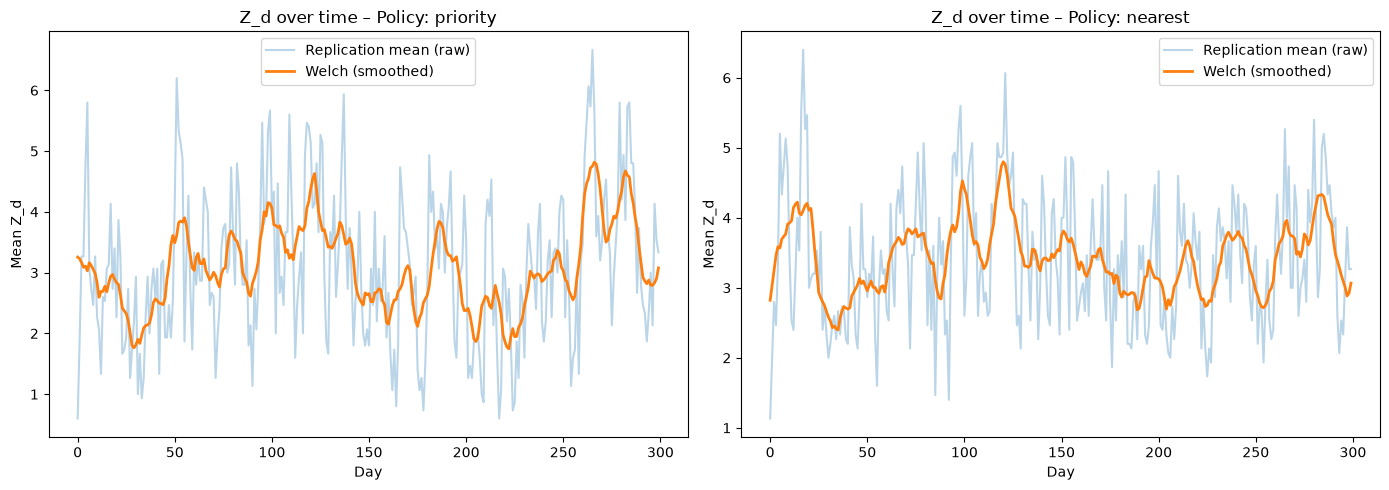

In [21]:
# NEW: Task 1 Warm-up – Determination via Welch's Method
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def run_replications_for_warmup(policy, n_reps=15, sim_days=300, base_seed=1000):
    """Runs multiple independent replications, returns Z_d time series per replication."""
    all_Zd = []
    for r in tqdm(range(n_reps), desc=f"Warm-up Reps ({policy})"):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=R1_SUCCESS_PROB, depot=DEPOT,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()
        Zd_series = [rec['Z_d'] for rec in sim.daily_records]
        all_Zd.append(Zd_series)
    return np.array(all_Zd)  # shape (n_reps, sim_days)

def welch_moving_average(data, window=5):
    """data: (n_reps, n_days) -> averages across replications, then applies moving window."""
    mean_across_reps = data.mean(axis=0)
    smoothed = np.array([
        mean_across_reps[max(0, t - window): t + window + 1].mean()
        for t in range(len(mean_across_reps))
    ])
    return mean_across_reps, smoothed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, policy in zip(axes, ('priority', 'nearest')):
    data = run_replications_for_warmup(policy, n_reps=15, sim_days=300)
    raw, smoothed = welch_moving_average(data, window=5)
    ax.plot(raw, alpha=0.3, label='Replication mean (raw)')
    ax.plot(smoothed, linewidth=2, label='Welch (smoothed)')
    ax.set_title(f'Z_d over time – Policy: {policy}')
    ax.set_xlabel('Day')
    ax.set_ylabel('Mean Z_d')
    ax.legend()
plt.tight_layout()
plt.show()

Eval Reps (priority):   0%|          | 0/30 [00:00<?, ?it/s]

Eval Reps (nearest):   0%|          | 0/30 [00:00<?, ?it/s]

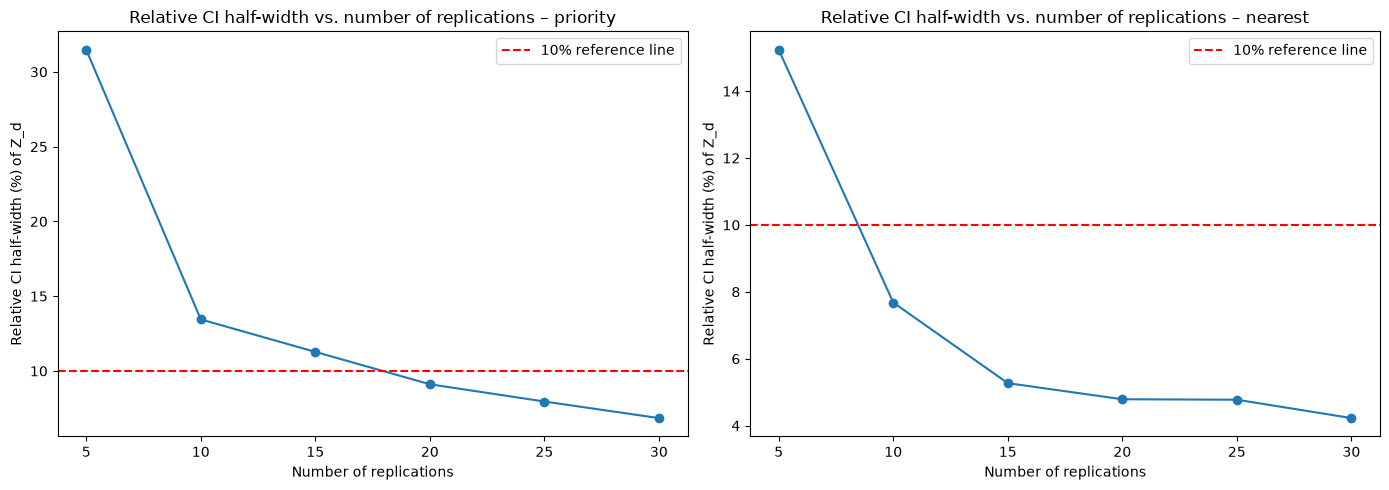

priority: mean Z_d = 3.065, 95%-CI = [2.855, 3.275], n_reps = 30
nearest: mean Z_d = 3.377, 95%-CI = [3.234, 3.519], n_reps = 30


In [22]:
# NEW: Task 1 (continued) – Determine number of replications via CI width
from scipy import stats

WARMUP_DAYS = 40          # determined based on Welch analysis
EVAL_HORIZON_DAYS = 200   # days AFTER warm-up used for evaluation
SIM_DAYS = WARMUP_DAYS + EVAL_HORIZON_DAYS

def run_replications_eval(policy, n_reps, sim_days=SIM_DAYS, base_seed=2000):
    """Runs n_reps replications and returns the mean Z_d (after warm-up) per replication (one value per replication)."""
    rep_means = []
    for r in tqdm(range(n_reps), desc=f"Eval Reps ({policy})"):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=R1_SUCCESS_PROB, depot=DEPOT,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()
        Zd_after_warmup = [
            rec['Z_d'] for rec in sim.daily_records if rec['day'] > WARMUP_DAYS
        ]
        rep_means.append(np.mean(Zd_after_warmup))
    return np.array(rep_means)

def ci_half_width(data, confidence=0.95):
    """95% confidence interval half-width of the mean (t-distribution)."""
    n = len(data)
    if n < 2:
        return np.nan
    se = stats.sem(data)
    t_val = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    return t_val * se

# rep_counts line stays the same, plot labels
rep_counts = [5, 10, 15, 20, 25, 30]
MAX_REPS = max(rep_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results = {}

for ax, policy in zip(axes, ('priority', 'nearest')):
    # Draw the maximum number of replications once, then evaluate subsets (saves computation time compared to a separate run for each rep_count)
    all_rep_means = run_replications_eval(policy, n_reps=MAX_REPS)
    results[policy] = all_rep_means

    half_widths = []
    rel_half_widths = []
    for n in rep_counts:
        subset = all_rep_means[:n]
        hw = ci_half_width(subset)
        half_widths.append(hw)
        rel_half_widths.append(hw / subset.mean() * 100)  # relative width in %

    ax.plot(rep_counts, rel_half_widths, marker='o')
    ax.axhline(10, color='red', linestyle='--', label='10% reference line')
    ax.set_title(f'Relative CI half-width vs. number of replications – {policy}')
    ax.set_xlabel('Number of replications')
    ax.set_ylabel('Relative CI half-width (%) of Z_d')
    ax.legend()

plt.tight_layout()
plt.show()

# Summary table prints
for policy in ('priority', 'nearest'):
    data = results[policy]
    hw = ci_half_width(data)
    print(f"{policy}: mean Z_d = {data.mean():.3f}, "
          f"95%-CI = [{data.mean()-hw:.3f}, {data.mean()+hw:.3f}], "
          f"n_reps = {len(data)}")

In [23]:
# NEW: Final configuration for Tasks 2–9
WARMUP_DAYS = 40
EVAL_HORIZON_DAYS = 200
SIM_DAYS = WARMUP_DAYS + EVAL_HORIZON_DAYS   # = 240
N_REPLICATIONS = 20

In [24]:
# NEW – Task 2: KPI computation for both policies (baseline performance)
import pandas as pd

def compute_kpis_for_sim(sim, warmup_days=WARMUP_DAYS):
    """Computes all KPIs defined in the PDF from one simulation run, excluding warm-up days."""

    # Filter data after warm-up
    daily = [r for r in sim.daily_records if r['day'] > warmup_days]
    jobs = [r for r in sim.job_records if r['day'] > warmup_days]
    tech_days = [r for r in sim.tech_day_records if r['day'] > warmup_days]

    # 1) Average daily service performance score (Z_d)
    avg_Zd = np.mean([r['Z_d'] for r in daily])

    # 2) First-time fix rate for repairs
    # First attempts: request_type == 'repair' and second_attempt == False
    # second_attempt is only set in job_records for completed/failed events
    first_attempts = [
        r for r in jobs
        if r['request_type'] == 'repair'
        and r.get('second_attempt', False) == False
        and r['status'] in ('completed', 'failed_first_attempt')
    ]
    successful_first = [r for r in first_attempts if r['status'] == 'completed']
    first_time_fix_rate = (
        len(successful_first) / len(first_attempts) if first_attempts else np.nan
    )

    # 3) Probability of a failed first repair attempt
    prob_failed_first = (
        1 - first_time_fix_rate if not np.isnan(first_time_fix_rate) else np.nan
    )

    # 4) Average daily travel time per technician type
    df_tech = pd.DataFrame(tech_days)
    avg_travel_by_type = df_tech.groupby('tech_type')['travel_time'].mean().to_dict()

    # 5) Utilization per technician type
    df_tech['utilization'] = df_tech['working_time'] / MINUTES_PER_DAY
    avg_utilization_by_type = df_tech.groupby('tech_type')['utilization'].mean().to_dict()

    # 6) Workload balance (AAD from daily average utilization)
    aad_per_day = []
    for day, group in df_tech.groupby('day'):
        day_mean_util = group['utilization'].mean()
        aad = (group['utilization'] - day_mean_util).abs().mean()
        aad_per_day.append(aad)
    workload_aad = np.mean(aad_per_day)

    # 7) Average waiting time (arrival -> successful completion)
    # Only jobs that were ultimately successfully completed.
    # Second-attempt successes count as the day of the successful 2nd attempt.
    completed_jobs = [r for r in jobs if r['status'] == 'completed']
    waiting_days_list = [r['day'] - r['day_created'] for r in completed_jobs]
    avg_waiting_days = np.mean(waiting_days_list) if waiting_days_list else np.nan
    # Conversion to minutes (based on 24h calendar day) for reference
    avg_waiting_minutes = avg_waiting_days * MINUTES_PER_CALENDAR_DAY

    return dict(
        avg_Zd=avg_Zd,
        first_time_fix_rate=first_time_fix_rate,
        prob_failed_first_attempt=prob_failed_first,
        avg_travel_R1=avg_travel_by_type.get('R1', np.nan),
        avg_travel_R2=avg_travel_by_type.get('R2', np.nan),
        avg_travel_install=avg_travel_by_type.get('install', np.nan),
        util_R1=avg_utilization_by_type.get('R1', np.nan),
        util_R2=avg_utilization_by_type.get('R2', np.nan),
        util_install=avg_utilization_by_type.get('install', np.nan),
        workload_aad=workload_aad,
        avg_waiting_days=avg_waiting_days,
        avg_waiting_minutes=avg_waiting_minutes,
    )


def run_kpi_replications(policy, n_reps=N_REPLICATIONS, sim_days=SIM_DAYS, base_seed=3000):
    """Runs n_reps replications and returns a list of KPI dicts."""
    all_kpis = []
    for r in tqdm(range(n_reps), desc=f"KPI Reps ({policy})"):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=R1_SUCCESS_PROB, depot=DEPOT,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()
        all_kpis.append(compute_kpis_for_sim(sim))
    return pd.DataFrame(all_kpis)


def summarize_kpis(df_kpis, confidence=0.95):
    """Mean + CI half-width per column (KPI) across replications."""
    summary = {}
    for col in df_kpis.columns:
        data = df_kpis[col].dropna().values
        mean = data.mean()
        hw = ci_half_width(data, confidence=confidence)
        summary[col] = (mean, hw)
    return summary


# Evaluate both policies
kpi_results = {}
for policy in ('priority', 'nearest'):
    df_kpis = run_kpi_replications(policy)
    kpi_results[policy] = summarize_kpis(df_kpis)

# Build results table
rows = []
kpi_labels = {
    'avg_Zd': 'Avg. daily service score (Z_d)',
    'first_time_fix_rate': 'First-time fix rate (Repairs)',
    'prob_failed_first_attempt': 'P(failed first attempt)',
    'avg_travel_R1': 'Avg. daily travel time R1 (min)',
    'avg_travel_R2': 'Avg. daily travel time R2 (min)',
    'avg_travel_install': 'Avg. daily travel time Install (min)',
    'util_R1': 'Utilization R1',
    'util_R2': 'Utilization R2',
    'util_install': 'Utilization Install',
    'workload_aad': 'Workload balance (AAD)',
    'avg_waiting_days': 'Avg. waiting time (days)',
    'avg_waiting_minutes': 'Avg. waiting time (min)',
}

for key, label in kpi_labels.items():
    row = {'KPI': label}
    for policy in ('priority', 'nearest'):
        mean, hw = kpi_results[policy][key]
        row[f'{policy} (mean)'] = round(mean, 3)
        row[f'{policy} (95% CI half-width)'] = round(hw, 3)
    rows.append(row)

kpi_table = pd.DataFrame(rows)
kpi_table

KPI Reps (priority):   0%|          | 0/20 [00:00<?, ?it/s]

KPI Reps (nearest):   0%|          | 0/20 [00:00<?, ?it/s]

,KPI,priority (mean),priority (95% CI half-width),nearest (mean),nearest (95% CI half-width)
0,Avg. daily service score (Z_d),3.051,0.349,3.385,0.225
1,First-time fix rate (Repairs),0.992,0.001,0.978,0.001
2,P(failed first attempt),0.008,0.001,0.022,0.001
3,Avg. daily travel time R1 (min),212.193,2.425,163.885,2.109
4,Avg. daily travel time R2 (min),273.403,0.578,233.523,0.524
5,Avg. daily travel time Install (min),199.311,0.521,200.424,0.490
6,Utilization R1,0.733,0.009,0.569,0.008
7,Utilization R2,0.918,0.001,0.921,0.001
8,Utilization Install,0.921,0.001,0.920,0.001
9,Workload balance (AAD),0.105,0.003,0.182,0.004


Task 3: P(failed first attempt) – Detailed evaluation

Basis: 20 replications, warm-up 40 days, evaluation horizon 200 days

Policy: PRIORITY
  P(failed first attempt | attempted)  = 0.0083  95%-CI: [0.0074, 0.0092]
  First-time fix rate (complement)     = 0.9917  95%-CI: [0.9908, 0.9926]
  Analytical upper bound (if all first attempts by R1): 0.1000
  -> Estimate is lower since R2 first attempts never fail.

Policy: NEAREST
  P(failed first attempt | attempted)  = 0.0218  95%-CI: [0.0208, 0.0228]
  First-time fix rate (complement)     = 0.9782  95%-CI: [0.9772, 0.9792]
  Analytical upper bound (if all first attempts by R1): 0.1000
  -> Estimate is lower since R2 first attempts never fail.



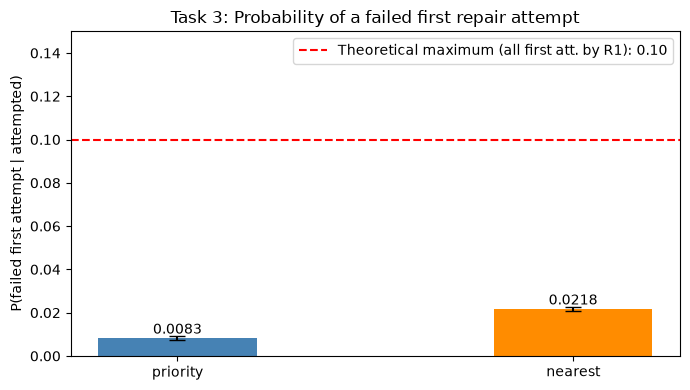

In [ ]:
# NEW – Task 3: Estimate the probability of a failed first repair attempt P(failed first attempt)

# Definition (per PDF): fraction of first repair attempts that fail, conditional on actually executed first attempts.
# Analytical decomposition as sanity check: P(fail | attempted) = P(first attempt by R1 | attempted)
# * (1 - R1_success), since R2 first attempts always succeed, only R1 can fail with prob. 0.10.
# Data basis: same replications as Task 2 (kpi_results) -> no separate simulation runs needed.

print("Task 3: P(failed first attempt) – Detailed evaluation")
print(f"\nBasis: {N_REPLICATIONS} replications, warm-up {WARMUP_DAYS} days, "
      f"evaluation horizon {EVAL_HORIZON_DAYS} days\n")

for policy in ('priority', 'nearest'):
    mean_p, hw_p   = kpi_results[policy]['prob_failed_first_attempt']
    mean_ftf, hw_ftf = kpi_results[policy]['first_time_fix_rate']

    print(f"Policy: {policy.upper()}")
    print(f"  P(failed first attempt | attempted)  = {mean_p:.4f}"
          f"  95%-CI: [{mean_p - hw_p:.4f}, {mean_p + hw_p:.4f}]")
    print(f"  First-time fix rate (complement)     = {mean_ftf:.4f}"
          f"  95%-CI: [{mean_ftf - hw_ftf:.4f}, {mean_ftf + hw_ftf:.4f}]")
    print(f"  Analytical upper bound "
          f"(if all first attempts by R1): {1 - R1_SUCCESS_PROB:.4f}")
    print(f"  -> Estimate is lower since R2 first attempts never fail.\n")

# Visualization
fig, ax = plt.subplots(figsize=(7, 4))
policies_list = ['priority', 'nearest']
means = [kpi_results[p]['prob_failed_first_attempt'][0] for p in policies_list]
hws   = [kpi_results[p]['prob_failed_first_attempt'][1] for p in policies_list]

bars = ax.bar(policies_list, means,
              color=['steelblue', 'darkorange'],
              yerr=hws, capsize=6, width=0.4)
ax.axhline(1 - R1_SUCCESS_PROB, color='red', linestyle='--',
           label=f'Theoretical maximum (all first att. by R1): '
                 f'{1 - R1_SUCCESS_PROB:.2f}')
ax.set_ylabel('P(failed first attempt | attempted)')
ax.set_title('Task 3: Probability of a failed first repair attempt')
ax.set_ylim(0, 0.15)
ax.legend()
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + 0.002, f'{mean:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Starte 2^3 Factorial Experiment ...


Factorial-Kombinationen:   0%|          | 0/8 [00:00<?, ?it/s]

  Done: R1=3, R2=3, Install=3, Policy=priority: mean Z_d=3.065
  Done: R1=3, R2=3, Install=3, Policy=nearest: mean Z_d=3.495
  Done: R1=3, R2=3, Install=4, Policy=priority: mean Z_d=1.116
  Done: R1=3, R2=3, Install=4, Policy=nearest: mean Z_d=1.764
  Done: R1=3, R2=4, Install=3, Policy=priority: mean Z_d=0.594
  Done: R1=3, R2=4, Install=3, Policy=nearest: mean Z_d=1.167
  Done: R1=3, R2=4, Install=4, Policy=priority: mean Z_d=0.462
  Done: R1=3, R2=4, Install=4, Policy=nearest: mean Z_d=0.722
  Done: R1=4, R2=3, Install=3, Policy=priority: mean Z_d=1.176
  Done: R1=4, R2=3, Install=3, Policy=nearest: mean Z_d=3.140
  Done: R1=4, R2=3, Install=4, Policy=priority: mean Z_d=0.958
  Done: R1=4, R2=3, Install=4, Policy=nearest: mean Z_d=1.737
  Done: R1=4, R2=4, Install=3, Policy=priority: mean Z_d=0.476
  Done: R1=4, R2=4, Install=3, Policy=nearest: mean Z_d=1.179
  Done: R1=4, R2=4, Install=4, Policy=priority: mean Z_d=0.468
  Done: R1=4, R2=4, Install=4, Policy=nearest: mean Z_d=0.722


,R1_level,R2_level,Install_level,num_R1,num_R2,num_Install,priority_mean_Zd,priority_CI_hw,nearest_mean_Zd,nearest_CI_hw
0,-1,-1,-1,3,3,3,3.065,0.281,3.496,0.193
1,-1,-1,1,3,3,4,1.116,0.076,1.764,0.098
2,-1,1,-1,3,4,3,0.594,0.039,1.167,0.067
3,-1,1,1,3,4,4,0.462,0.022,0.722,0.021
4,1,-1,-1,4,3,3,1.176,0.058,3.140,0.185
5,1,-1,1,4,3,4,0.958,0.048,1.737,0.104
6,1,1,-1,4,4,3,0.476,0.027,1.179,0.068
7,1,1,1,4,4,4,0.468,0.025,0.722,0.021



--- Main effects and interaction effects (target KPI: avg Z_d) ---
Negative effect = reduction in Z_d = performance improvement

Policy: priority
  Main effect A (R1)                 : -0.5401
  Main effect B (R2)                 : -1.0789
  Main effect C (Install)            : -0.5770
  Interaction AB (R1×R2)             : +0.4840
  Interaction AC (R1×Install)        : +0.4636
  Interaction BC (R2×Install)        : +0.5069
  Interaction ABC (R1×R2×Install)    : -0.4017

Policy: nearest
  Main effect A (R1)                 : -0.0928
  Main effect B (R2)                 : -1.5866
  Main effect C (Install)            : -1.0090
  Interaction AB (R1×R2)             : +0.0989
  Interaction AC (R1×Install)        : +0.0790
  Interaction BC (R2×Install)        : +0.5581
  Interaction ABC (R1×R2×Install)    : -0.0851



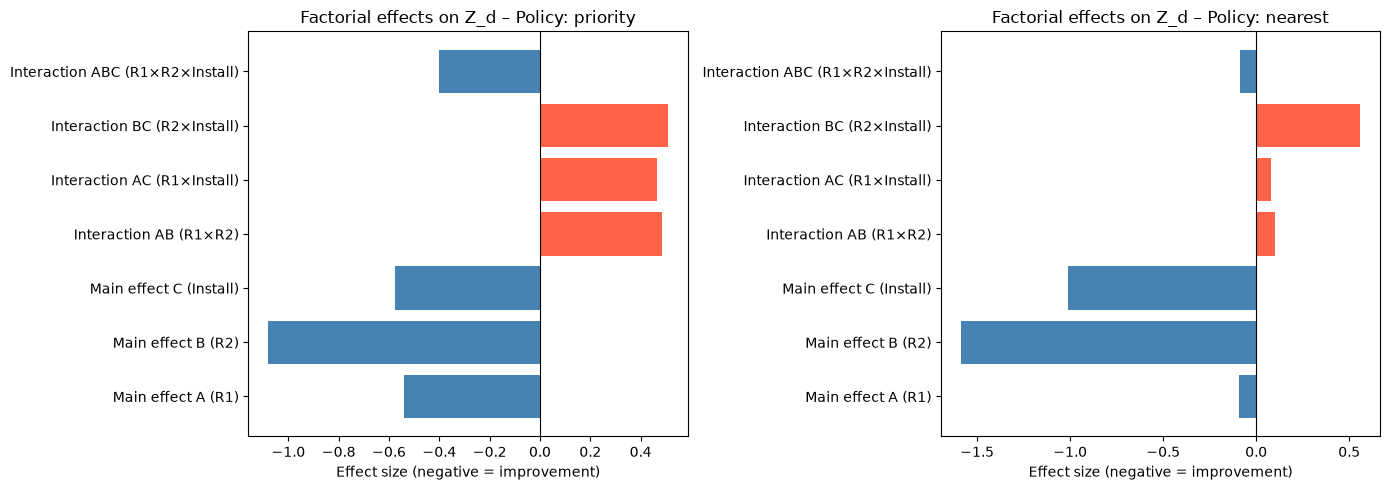

In [ ]:
# NEW – Task 4: 2^3 Factorial Staffing Experiment
# Factors: R1 (+0 or +1), R2 (+0 or +1), Install (+0 or +1)
# Level -1: current staffing (3,3,3), Level +1: current staffing + 1 (4,4,4)
# 2^3 = 8 combinations, both policies, N_REPLICATIONS replications each

from itertools import product

# Define factor levels (coded as -1 / +1 for effect computation)
STAFFING_BASE = {'R1': NUM_R1, 'R2': NUM_R2, 'install': NUM_INSTALL}  # (3,3,3)
STAFFING_LEVELS = {-1: 0, +1: 1}  # offset from base value

def get_staffing(r1_lvl, r2_lvl, inst_lvl):
    """Returns (num_R1, num_R2, num_install) for a given factor level vector."""
    return (
        STAFFING_BASE['R1'] + STAFFING_LEVELS[r1_lvl],
        STAFFING_BASE['R2'] + STAFFING_LEVELS[r2_lvl],
        STAFFING_BASE['install'] + STAFFING_LEVELS[inst_lvl],
    )

# all 8 combonations
factor_combinations = list(product([-1, +1], repeat=3))
# rows: (r1_lvl, r2_lvl, inst_lvl)

def run_factorial_scenario(num_R1, num_R2, num_install, policy,
                           n_reps=N_REPLICATIONS, sim_days=SIM_DAYS,
                           base_seed=5000):
    """Runs n_reps replications for one staffing combination and policy. Returns avg_Zd per replication (main KPI for factorial analysis)."""
    rep_Zd = []
    rep_kpis = []
    for r in range(n_reps):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=num_R1, num_R2=num_R2, num_install=num_install,
            R1_success=R1_SUCCESS_PROB, depot=DEPOT,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()
        kpis = compute_kpis_for_sim(sim)
        rep_Zd.append(kpis['avg_Zd'])
        rep_kpis.append(kpis)
    return np.array(rep_Zd), pd.DataFrame(rep_kpis)

# Run all scenarios
print("Starte 2^3 Factorial Experiment ...")
factorial_results = {}  # key: (r1_lvl, r2_lvl, inst_lvl, policy) -> array of avg_Zd

for r1_lvl, r2_lvl, inst_lvl in tqdm(factor_combinations, desc="Factorial-Kombinationen"):
    num_R1, num_R2, num_install = get_staffing(r1_lvl, r2_lvl, inst_lvl)
    for policy in ('priority', 'nearest'):
        key = (r1_lvl, r2_lvl, inst_lvl, policy)
        Zd_arr, _ = run_factorial_scenario(num_R1, num_R2, num_install, policy)
        factorial_results[key] = Zd_arr
        print(f"  Done: R1={num_R1}, R2={num_R2}, Install={num_install}, "
              f"Policy={policy}: mean Z_d={Zd_arr.mean():.3f}")

# Overview table
rows_fact = []
for r1_lvl, r2_lvl, inst_lvl in factor_combinations:
    num_R1, num_R2, num_install = get_staffing(r1_lvl, r2_lvl, inst_lvl)
    row = {
        'R1_level': r1_lvl, 'R2_level': r2_lvl, 'Install_level': inst_lvl,
        'num_R1': num_R1, 'num_R2': num_R2, 'num_Install': num_install,
    }
    for policy in ('priority', 'nearest'):
        arr = factorial_results[(r1_lvl, r2_lvl, inst_lvl, policy)]
        hw = ci_half_width(arr)
        row[f'{policy}_mean_Zd'] = round(arr.mean(), 3)
        row[f'{policy}_CI_hw'] = round(hw, 3)
    rows_fact.append(row)

df_factorial = pd.DataFrame(rows_fact)
print("\nOverview table – Factorial Experiment:")
display(df_factorial)

# Compute main effects and interaction effects
# Standard 2^k factorial formula: effect = contrast / (n_reps * 2^(k-1))
# Contrast X_i: sum(Y at X_i=+1) - sum(Y at X_i=-1) across all combinations

def compute_factorial_effects(results_dict, policy, factor_combinations, n_reps):
    """Computes main and interaction effects for one policy. Factor order: (R1, R2, Install) = (A, B, C)."""
    divisor = n_reps * 2 ** (3 - 1)  # = n_reps * 4 für k=3

    def contrast(fa, fb, fc):
        """Sum(Y * sign(fa*fb*fc)) across all 8 combinations."""
        total = 0.0
        for (r1, r2, inst) in factor_combinations:
            sign = fa(r1) * fb(r2) * fc(inst)
            arr = results_dict[(r1, r2, inst, policy)]
            total += sign * arr.mean() * n_reps
        return total / divisor

    ident = lambda x: 1   # identity element for uninvolved factors
    A = lambda x: x       # R1 factor
    B = lambda x: x       # R2 factor
    C = lambda x: x       # Install factor

    effects = {
        'Main effect A (R1)':          contrast(A, ident, ident),
        'Main effect B (R2)':          contrast(ident, B, ident),
        'Main effect C (Install)':     contrast(ident, ident, C),
        'Interaction AB (R1×R2)':      contrast(A, B, ident),
        'Interaction AC (R1×Install)': contrast(A, ident, C),
        'Interaction BC (R2×Install)': contrast(ident, B, C),
        'Interaction ABC (R1×R2×Install)': contrast(A, B, C),
    }
    return effects

print("\n--- Main effects and interaction effects (target KPI: avg Z_d) ---")
print("Negative effect = reduction in Z_d = performance improvement\n")
for policy in ('priority', 'nearest'):
    effects = compute_factorial_effects(
        factorial_results, policy, factor_combinations, N_REPLICATIONS
    )
    print(f"Policy: {policy}")
    for name, val in effects.items():
        print(f"  {name:35s}: {val:+.4f}")
    print()

# Visualization: effect diagram (Pareto-style)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, policy in zip(axes, ('priority', 'nearest')):
    effects = compute_factorial_effects(
        factorial_results, policy, factor_combinations, N_REPLICATIONS
    )
    names = list(effects.keys())
    vals = list(effects.values())
    colors = ['steelblue' if v < 0 else 'tomato' for v in vals]
    ax.barh(names, vals, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Factorial effects on Z_d – Policy: {policy}')
    ax.set_xlabel('Effect size (negative = improvement)')
plt.tight_layout()
plt.show()

Starting 3^3 Factorial Experiment (1080 simulation runs) ...
  10/54 Scenarios completed ...
  20/54 Scenarios completed ...
  30/54 Scenarios completed ...
  40/54 Scenarios completed ...
  50/54 Scenarios completed ...
Done!

Z_d by scenario and policy (means across replications):


policy                                nearest  priority  \
arrival_rate travel_label r1_success                      
60           adverse      0.80          2.859     1.566   
                          0.90          1.602     0.997   
                          0.95          1.031     0.829   
             baseline     0.80          1.034     0.426   
                          0.90          0.696     0.376   
                          0.95          0.533     0.363   
             favorable    0.80          0.467     0.256   
                          0.90          0.406     0.239   
                          0.95          0.385     0.247   
80           adverse      0.80         22.820   142.481   
                          0.90         15.000   120.094   
                          0.95          9.718    96.485   
             baseline     0.80          6.297     4.222   
                          0.90          3.308     3.226   
                          0.95          2.128     2.643   
             favorable    0.80          2.854     0.596   
                          0.90          1.688     0.552   
                          0.95          1.066     0.506   
100          adverse      0.80        376.300   257.716   
                          0.90        367.515   238.682   
                          0.95        364.608   232.804   
             baseline     0.80        105.885   155.358   
                          0.90         72.675   140.153   
                          0.95         55.902   133.524   
             favorable    0.80         13.930    30.760   
                          0.90          7.632    15.190   
                          0.95          4.735    10.738   

policy                                Differenz (priority - nearest)  
arrival_rate travel_label r1_success                                  
60           adverse      0.80                                -1.293  
                          0.90                                -0.605  
                          0.95                                -0.202  
             baseline     0.80                                -0.608  
                          0.90                                -0.320  
                          0.95                                -0.170  
             favorable    0.80                                -0.211  
                          0.90                                -0.167  
                          0.95                                -0.138  
80           adverse      0.80                               119.661  
                          0.90                               105.094  
                          0.95                                86.767  
             baseline     0.80                                -2.075  
                          0.90                                -0.082  
                          0.95                                 0.515  
             favorable    0.80                                -2.258  
                          0.90                                -1.136  
                          0.95                                -0.560  
100          adverse      0.80                              -118.584  
                          0.90                              -128.833  
                          0.95                              -131.804  
             baseline     0.80                                49.473  
                          0.90                                67.478  
                          0.95                                77.622  
             favorable    0.80                                16.830  
                          0.90                                 7.558  
                          0.95                                 6.003

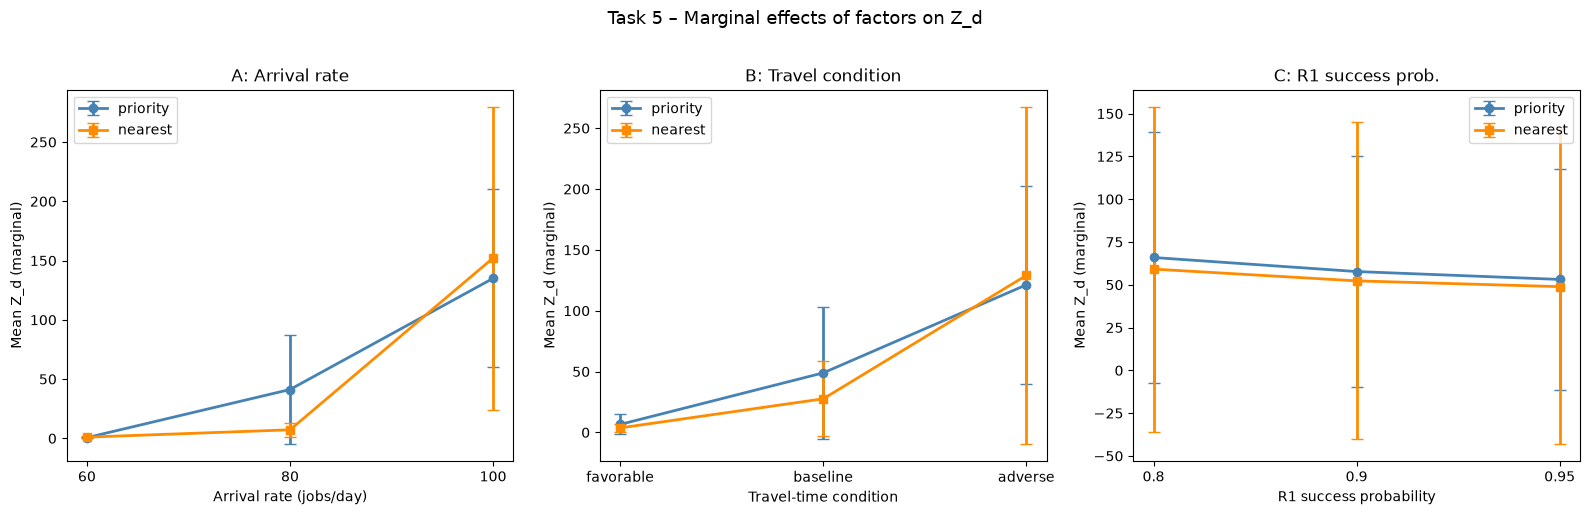

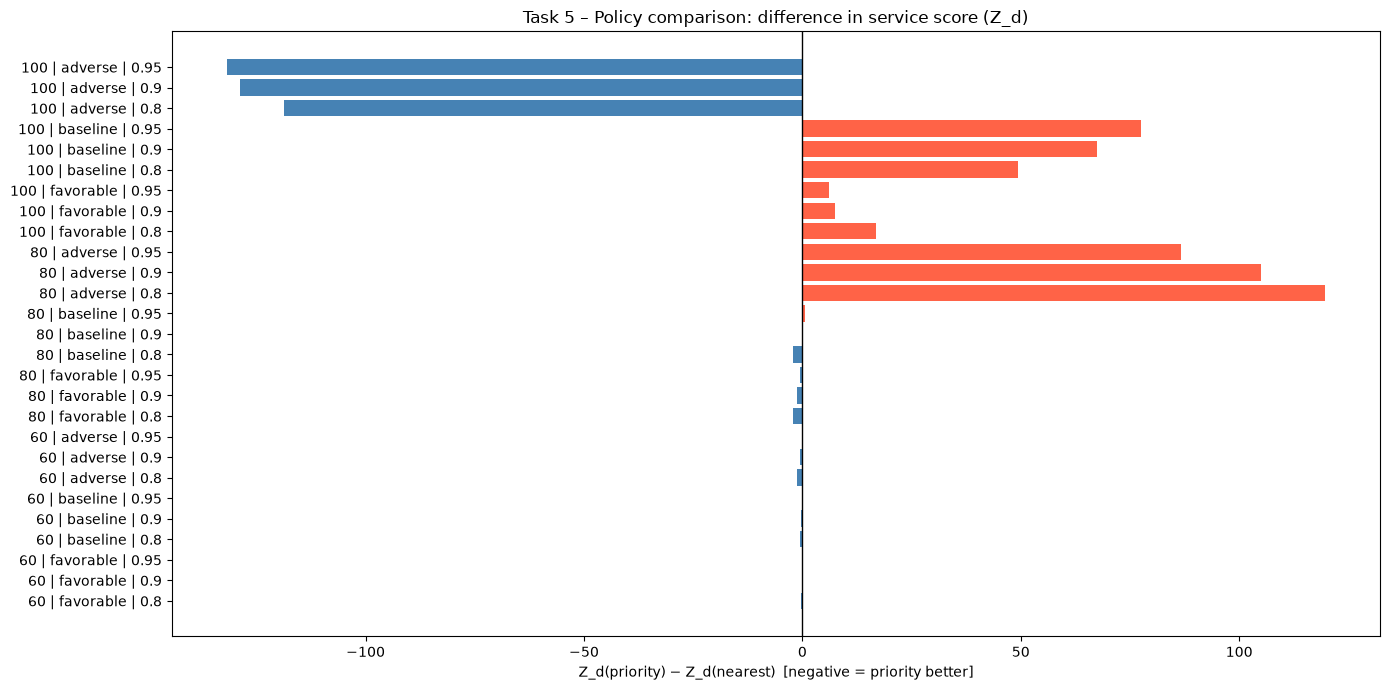

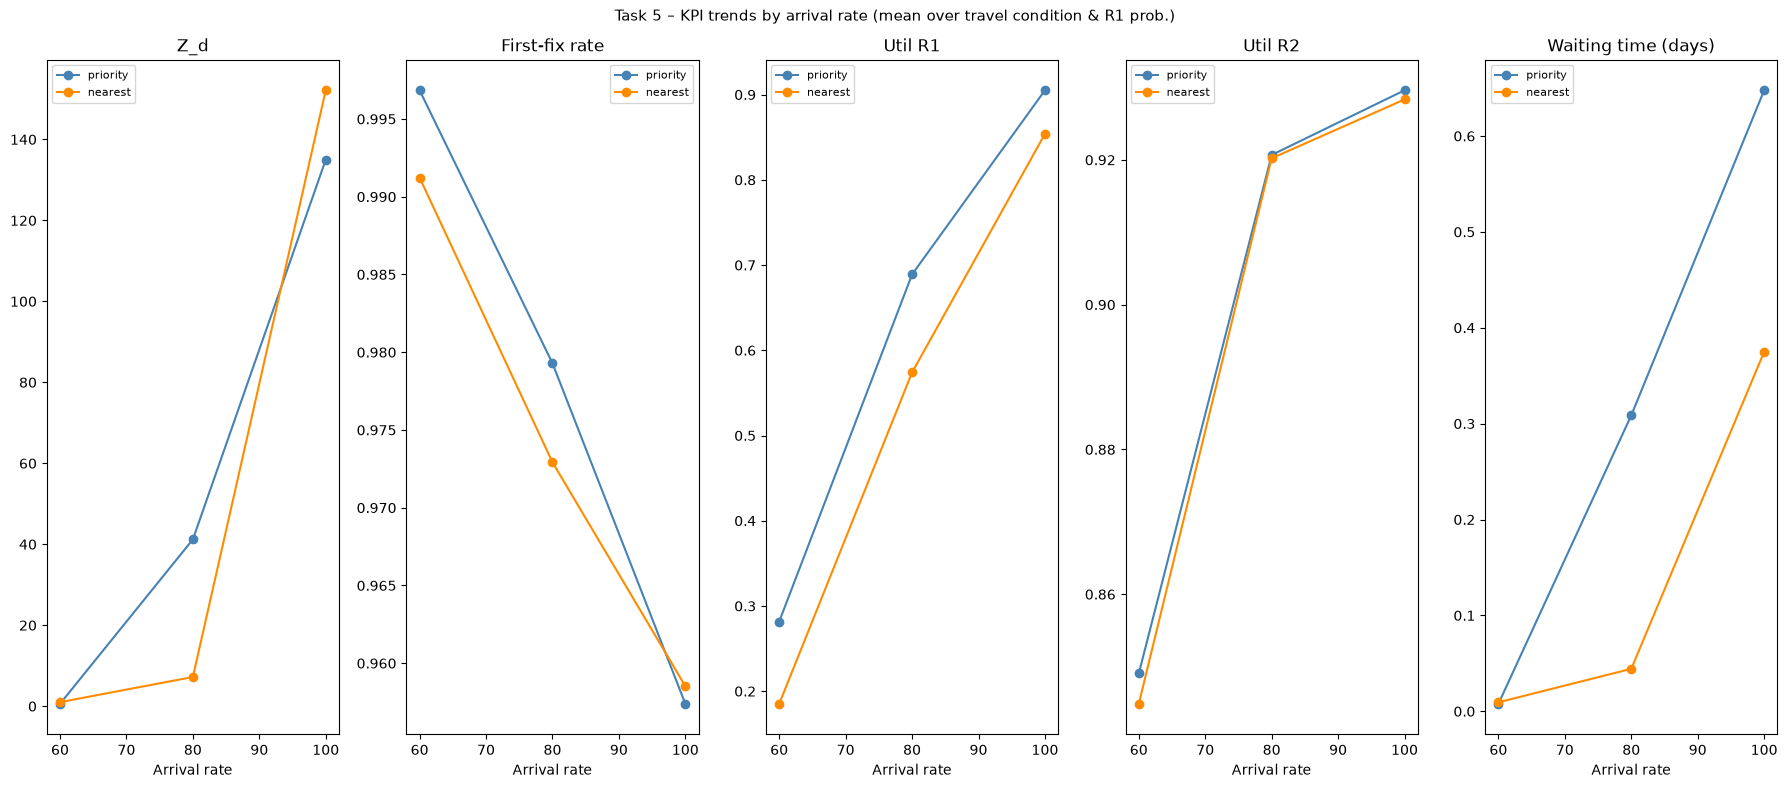

In [27]:
# NEW – Task 5: Full 3^3 Factorial Experiment
# Factors (3 levels each):
#   A: Daily arrival rate (arrivals_per_day): 60 / 80 (baseline) / 100
#   B: Travel-time condition (triangular parameters): favorable / baseline / adverse
#   C: R1 success probability: 0.80 / 0.90 (baseline) / 0.95
# 3^3 = 27 combinations × 2 policies × N_REPS_T5 replications

N_REPS_T5 = 20

# Define factor levels
ARRIVAL_RATE_LEVELS = [60, 80, 100]
TRAVEL_CONDITIONS = [
    {'label': 'favorable', 'low': 3,  'mode': 6.0, 'high': 9},
    {'label': 'baseline',  'low': 5,  'mode': 7.5, 'high': 12},
    {'label': 'adverse',   'low': 7,  'mode': 10,  'high': 15},
]
R1_SUCCESS_LEVELS = [0.80, 0.90, 0.95]

def run_scenario_t5(arrivals, travel, r1_success, policy,
                    n_reps=N_REPS_T5, sim_days=SIM_DAYS, base_seed=6000):
    """Runs n_reps replications for one factor scenario. Returns DataFrame with all KPIs per replication."""
    all_kpis = []
    # Seed offset so different scenarios use independent random streams
    seed_offset = (arrivals * 100
                   + int(r1_success * 1000)
                   + TRAVEL_CONDITIONS.index(travel) * 10000)
    for r in range(n_reps):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + seed_offset + r,
            sim_days=sim_days,
            arrivals_per_day=arrivals,
            p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=r1_success, depot=DEPOT,
            travel_base=TRAVEL_BASE_MIN,
            travel_low=travel['low'],
            travel_mode=travel['mode'],
            travel_high=travel['high'],
        )
        sim.run()
        all_kpis.append(compute_kpis_for_sim(sim))
    return pd.DataFrame(all_kpis)


# Run all 27 * 2 scenarios
print(f"Starting 3^3 Factorial Experiment "
      f"({len(ARRIVAL_RATE_LEVELS)**3 * 2 * N_REPS_T5} simulation runs) ...")

t5_records = []
scenario_idx = 0
total_scenarios = len(ARRIVAL_RATE_LEVELS) * len(TRAVEL_CONDITIONS) * len(R1_SUCCESS_LEVELS) * 2

for arr in ARRIVAL_RATE_LEVELS:
    for trav in TRAVEL_CONDITIONS:
        for r1s in R1_SUCCESS_LEVELS:
            for policy in ('priority', 'nearest'):
                scenario_idx += 1
                df_rep = run_scenario_t5(arr, trav, r1s, policy)

                row = {
                    'arrival_rate':      arr,
                    'travel_label':      trav['label'],
                    'travel_mean':       round((trav['low']+trav['mode']+trav['high'])/3, 2),
                    'r1_success':        r1s,
                    'policy':            policy,
                }
                # Mean + CI for each KPI
                for col in df_rep.columns:
                    data = df_rep[col].dropna().values
                    row[f'{col}_mean'] = round(data.mean(), 4)
                    row[f'{col}_ci_hw'] = round(ci_half_width(data), 4)

                t5_records.append(row)
                if scenario_idx % 10 == 0:
                    print(f"  {scenario_idx}/{total_scenarios} Scenarios completed ...")

df_t5 = pd.DataFrame(t5_records)
print("Done!\n")

# Overview table
t5_pivot = df_t5.pivot_table(
    index=['arrival_rate', 'travel_label', 'r1_success'],
    columns='policy',
    values='avg_Zd_mean'
).round(3)
t5_pivot['Differenz (priority - nearest)'] = (
    t5_pivot['priority'] - t5_pivot['nearest']
).round(3)
print("Z_d by scenario and policy (means across replications):")
display(t5_pivot)

# Marginal effects plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

factor_cfg = [
    ('arrival_rate',  ARRIVAL_RATE_LEVELS,  'Arrival rate (jobs/day)',       'A: Arrival rate'),
    ('travel_label',  [t['label'] for t in TRAVEL_CONDITIONS],
                                            'Travel-time condition',          'B: Travel condition'),
    ('r1_success',    R1_SUCCESS_LEVELS,    'R1 success probability',        'C: R1 success prob.'),
]

for ax, (col, levels, xlabel, title) in zip(axes, factor_cfg):
    for policy, color, marker in zip(
        ('priority', 'nearest'),
        ('steelblue', 'darkorange'),
        ('o', 's')
    ):
        # Marginalmittelwert: über alle anderen Faktorstufen mitteln
        means = []
        cis   = []
        sub = df_t5[df_t5['policy'] == policy]
        for lvl in levels:
            subset = sub[sub[col] == lvl]['avg_Zd_mean']
            means.append(subset.mean())
            cis.append(subset.std() / np.sqrt(len(subset))
                       * stats.t.ppf(0.975, df=len(subset)-1))

        ax.errorbar(range(len(levels)), means, yerr=cis,
                    label=policy, color=color, marker=marker,
                    capsize=4, linewidth=2)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels([str(l) for l in levels])

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean Z_d (marginal)')
    ax.legend()

plt.suptitle('Task 5 – Marginal effects of factors on Z_d', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Policy comparison: Difference Z_d(priority) - Z_d(nearest)
# Negative value = Priority better; positive value = Nearest better
df_diff = df_t5.copy()
df_diff = df_diff.sort_values(['arrival_rate','travel_label','r1_success','policy'])

df_pri = df_t5[df_t5['policy'] == 'priority'].set_index(
    ['arrival_rate', 'travel_label', 'r1_success'])
df_nea = df_t5[df_t5['policy'] == 'nearest'].set_index(
    ['arrival_rate', 'travel_label', 'r1_success'])
df_delta = (df_pri['avg_Zd_mean'] - df_nea['avg_Zd_mean']).reset_index()
df_delta.columns = ['arrival_rate', 'travel_label', 'r1_success', 'delta_Zd']
df_delta['scenario'] = (df_delta['arrival_rate'].astype(str) + ' | '
                         + df_delta['travel_label'] + ' | '
                         + df_delta['r1_success'].astype(str))

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['steelblue' if v < 0 else 'tomato' for v in df_delta['delta_Zd']]
ax.barh(df_delta['scenario'], df_delta['delta_Zd'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Z_d(priority) − Z_d(nearest)  [negative = priority better]')
ax.set_title('Task 5 – Policy comparison: difference in service score (Z_d)')
plt.tight_layout()
plt.show()

# KPI trends
kpi_cols_plot = ['avg_Zd_mean', 'first_time_fix_rate_mean',
                 'util_R1_mean', 'util_R2_mean', 'avg_waiting_days_mean']
kpi_plot_labels = ['Z_d', 'First-fix rate', 'Util R1', 'Util R2', 'Waiting time (days)']

fig, axes = plt.subplots(1, len(kpi_cols_plot), figsize=(18, 8))
for ax, kpi_col, kpi_lbl in zip(axes, kpi_cols_plot, kpi_plot_labels):
    pivot_data = df_t5.groupby(['policy', 'arrival_rate', 'r1_success'])[kpi_col].mean().unstack()
    for policy, color in zip(('priority', 'nearest'), ('steelblue', 'darkorange')):
        sub = df_t5[df_t5['policy'] == policy].groupby('arrival_rate')[kpi_col].mean()
        ax.plot(sub.index, sub.values, marker='o', label=policy, color=color)
    ax.set_title(kpi_lbl)
    ax.set_xlabel('Arrival rate')
    ax.legend(fontsize=8)
plt.suptitle('Task 5 – KPI trends by arrival rate (mean over travel condition & R1 prob.)', fontsize=11)
plt.tight_layout()
plt.show()

Loading baseline job data for spatial analysis ...


Baseline Jobs (priority):   0%|          | 0/20 [00:00<?, ?it/s]

  priority: 330562 job events after warm-up


Baseline Jobs (nearest):   0%|          | 0/20 [00:00<?, ?it/s]

  nearest: 326568 job events after warm-up


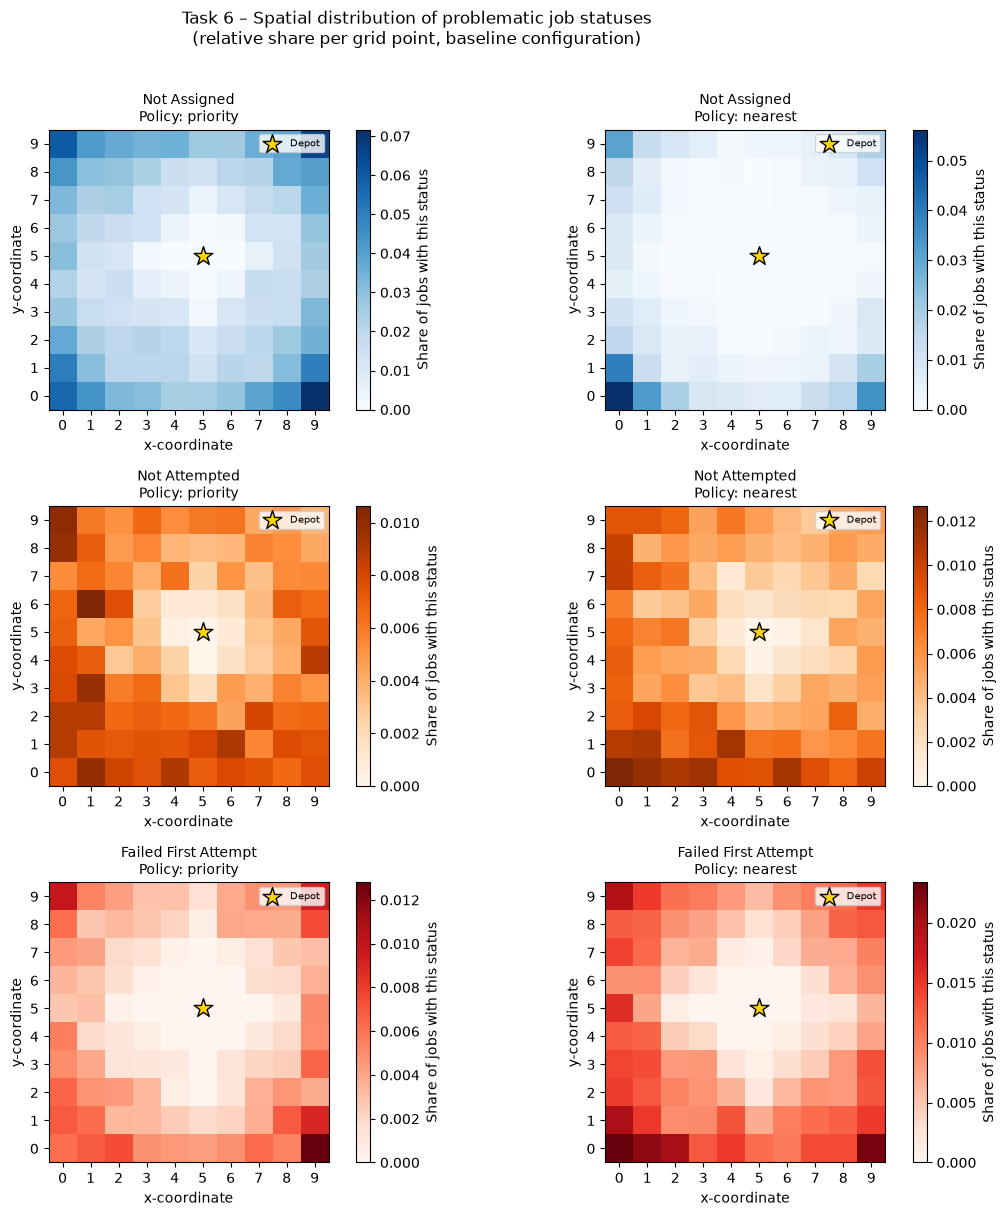

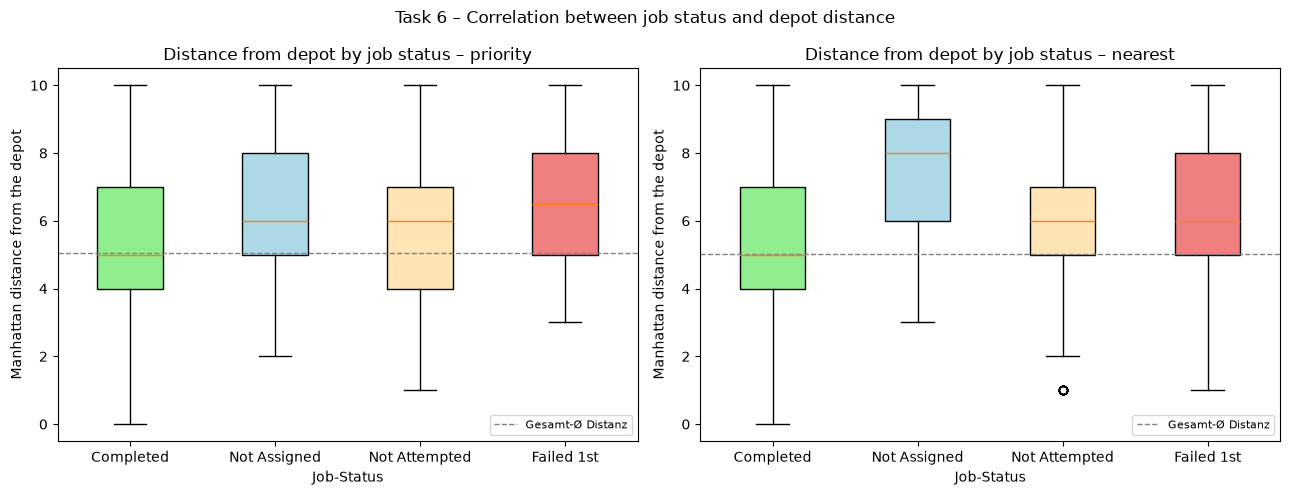

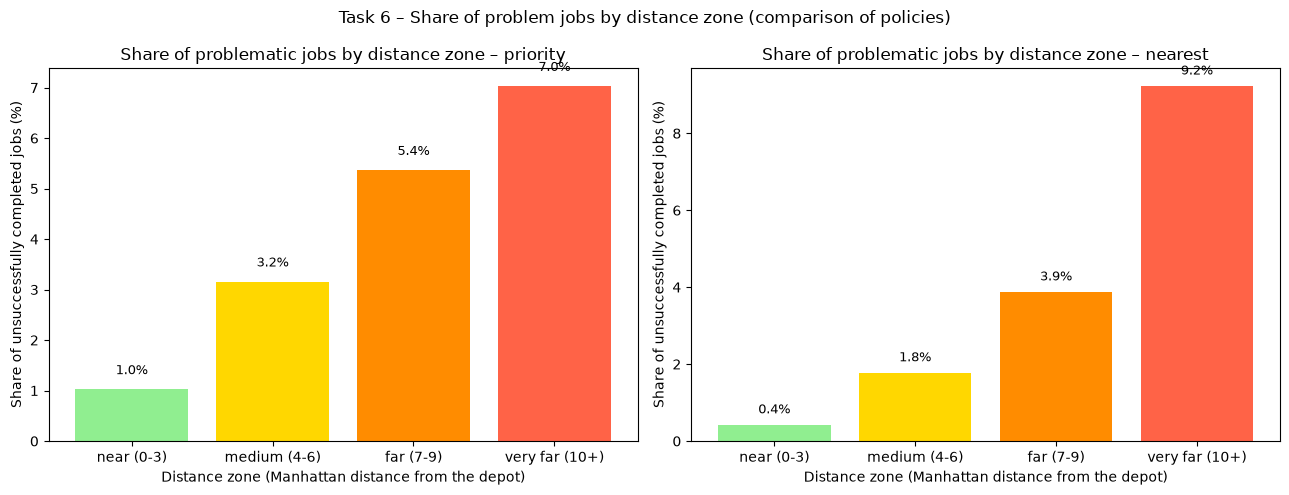


=== Task 6: Summary of spatial patterns ===

Policy: PRIORITY (n=330562 Job events after warm-up)
  Not Assigned             :  7701 (2.33%)
  Not Attempted            :  1880 (0.57%)
  Failed First Attempt     :  1064 (0.32%)

Policy: NEAREST (n=326568 Job events after warm-up)
  Not Assigned             :  1951 (0.60%)
  Not Attempted            :  1905 (0.58%)
  Failed First Attempt     :  2791 (0.85%)



In [34]:
# NEW – Task 6: Spatial distribution of not_assigned, not_attempted, and failed_first_attempt jobs under both policies.
# Data basis: baseline configuration (3/3/3 technicians, baseline parameters), same seeds as Task 2 (base_seed=3000) for consistency.

def run_baseline_with_jobs(policy, n_reps=N_REPLICATIONS,
                            sim_days=SIM_DAYS, base_seed=3000,
                            warmup_days=WARMUP_DAYS):
    """Like run_kpi_replications, but returns all job_records after warm-up."""
    all_jobs = []
    for r in tqdm(range(n_reps), desc=f"Baseline Jobs ({policy})"):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=R1_SUCCESS_PROB, depot=DEPOT,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()
        for rec in sim.job_records:
            if rec['day'] > warmup_days:
                all_jobs.append(rec)
    return pd.DataFrame(all_jobs)

print("Loading baseline job data for spatial analysis ...")
spatial_jobs = {}
for policy in ('priority', 'nearest'):
    spatial_jobs[policy] = run_baseline_with_jobs(policy)
    print(f"  {policy}: {len(spatial_jobs[policy])} job events after warm-up")

# Helper function: Populate location grid
def build_spatial_grid(df_jobs, status_filter):
    """Returns 10×10 grid with counts for a given status."""
    grid = np.zeros((GRID_SIZE, GRID_SIZE))
    sub = df_jobs[df_jobs['status'] == status_filter]
    for _, row in sub.iterrows():
        x, y = row['location']
        grid[y, x] += 1   # y = Zeile, x = Spalte
    return grid

def build_total_grid(df_jobs):
    """Total number of all jobs per grid point (denominator for relative heatmap)."""
    grid = np.zeros((GRID_SIZE, GRID_SIZE))
    for _, row in df_jobs.iterrows():
        x, y = row['location']
        grid[y, x] += 1
    return grid

# Absolute and relative heatmaps
STATUS_LIST = [
    ('not_assigned',         'Not Assigned',         'Blues'),
    ('not_attempted',        'Not Attempted',         'Oranges'),
    ('failed_first_attempt', 'Failed First Attempt',  'Reds'),
]

fig, axes = plt.subplots(
    len(STATUS_LIST), 2,
    figsize=(12, 4 * len(STATUS_LIST))
)
depot_x, depot_y = DEPOT

for row_idx, (status_key, status_label, cmap) in enumerate(STATUS_LIST):
    for col_idx, policy in enumerate(('priority', 'nearest')):
        ax = axes[row_idx, col_idx]
        df = spatial_jobs[policy]
        abs_grid = build_spatial_grid(df, status_key)
        total_grid = build_total_grid(df)

        # Relative frequency (proportion of jobs with this status at a grid point)
        # Grid points without jobs are assigned 0
        with np.errstate(invalid='ignore', divide='ignore'):
            rel_grid = np.where(total_grid > 0, abs_grid / total_grid, 0)

        im = ax.imshow(rel_grid, origin='lower', cmap=cmap,
                       vmin=0, aspect='equal')
        plt.colorbar(im, ax=ax, fraction=0.046,
                     label='Share of jobs with this status')

        # Select depot
        ax.scatter(depot_x, depot_y, marker='*', s=200,
                   color='gold', edgecolors='black', zorder=5, label='Depot')
        ax.set_title(f'{status_label}\nPolicy: {policy}', fontsize=10)
        ax.set_xlabel('x-coordinate')
        ax.set_ylabel('y-coordinate')
        ax.set_xticks(range(GRID_SIZE))
        ax.set_yticks(range(GRID_SIZE))
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Task 6 – Spatial distribution of problematic job statuses\n'
             '(relative share per grid point, baseline configuration)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Distance analysis: Distance from the depot by status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, policy in zip(axes, ('priority', 'nearest')):
    df = spatial_jobs[policy].copy()
    df['dist_depot'] = df['location'].apply(
        lambda loc: manhattan(loc, DEPOT)
    )
    # Box plot: Distance distribution by status
    status_order = ['completed', 'not_assigned', 'not_attempted', 'failed_first_attempt']
    status_labels_short = ['Completed', 'Not Assigned', 'Not Attempted', 'Failed 1st']
    data_by_status = [
        df[df['status'] == s]['dist_depot'].dropna().values
        for s in status_order
    ]
    bp = ax.boxplot(data_by_status, tick_labels=status_labels_short, patch_artist=True)
    colors_box = ['lightgreen', 'lightblue', 'moccasin', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)

    ax.axhline(df['dist_depot'].mean(), color='gray',
               linestyle='--', linewidth=1, label='Gesamt-Ø Distanz')
    ax.set_title(f'Distance from depot by job status – {policy}')
    ax.set_ylabel('Manhattan distance from the depot')
    ax.set_xlabel('Job-Status')
    ax.legend(fontsize=8)

plt.suptitle('Task 6 – Correlation between job status and depot distance',
             fontsize=12)
plt.tight_layout()
plt.show()

# Policy comparison: Status shares by distance zone
# Shows whether a policy systematically disadvantages certain zones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, policy in zip(axes, ('priority', 'nearest')):
    df = spatial_jobs[policy].copy()
    df['dist_depot'] = df['location'].apply(lambda loc: manhattan(loc, DEPOT))
    df['dist_zone'] = pd.cut(df['dist_depot'],
                              bins=[0, 3, 6, 9, 20],
                              labels=['near (0-3)', 'medium (4-6)',
                                      'far (7-9)', 'very far (10+)'],
                              include_lowest=True)

    # Proportion of problematic statuses (not_assigned + not_attempted + failed)
    df['problematic'] = df['status'].isin(
        ['not_assigned', 'not_attempted', 'failed_first_attempt']
    )
    zone_stats = df.groupby('dist_zone', observed=True)['problematic'].mean() * 100

    bars = ax.bar(zone_stats.index, zone_stats.values,
                  color=['lightgreen', 'gold', 'darkorange', 'tomato'])
    ax.set_title(f'Share of problematic jobs by distance zone – {policy}')
    ax.set_xlabel('Distance zone (Manhattan distance from the depot)')
    ax.set_ylabel('Share of unsuccessfully completed jobs (%)')
    for bar, val in zip(bars, zone_stats.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Task 6 – Share of problem jobs by distance zone (comparison of policies)',
             fontsize=12)
plt.tight_layout()
plt.show()

# Summary of spatial patterns
print("\n=== Task 6: Summary of spatial patterns ===\n")
for policy in ('priority', 'nearest'):
    df = spatial_jobs[policy]
    total = len(df)
    print(f"Policy: {policy.upper()} (n={total} Job events after warm-up)")
    for status_key, status_label, _ in STATUS_LIST:
        n = (df['status'] == status_key).sum()
        print(f"  {status_label:25s}: {n:5d} ({n/total*100:.2f}%)")
    print()

Generating baseline data for Tasks 7 and 8 ...


Baseline Full (priority):   0%|          | 0/20 [00:00<?, ?it/s]

  priority: 36000 technician-days, 330562 job events after warm-up


Baseline Full (nearest):   0%|          | 0/20 [00:00<?, ?it/s]

  nearest: 36000 technician-days, 326568 job events after warm-up

=== Task 7a: Average daily travel time per technician type ===

  priority  | R1      : 212.2 min  95%-CI [209.8, 214.6]
  priority  | R2      : 273.4 min  95%-CI [272.8, 274.0]
  priority  | install : 199.3 min  95%-CI [198.8, 199.8]
  nearest   | R1      : 163.9 min  95%-CI [161.8, 166.0]
  nearest   | R2      : 233.5 min  95%-CI [233.0, 234.0]
  nearest   | install : 200.4 min  95%-CI [199.9, 200.9]


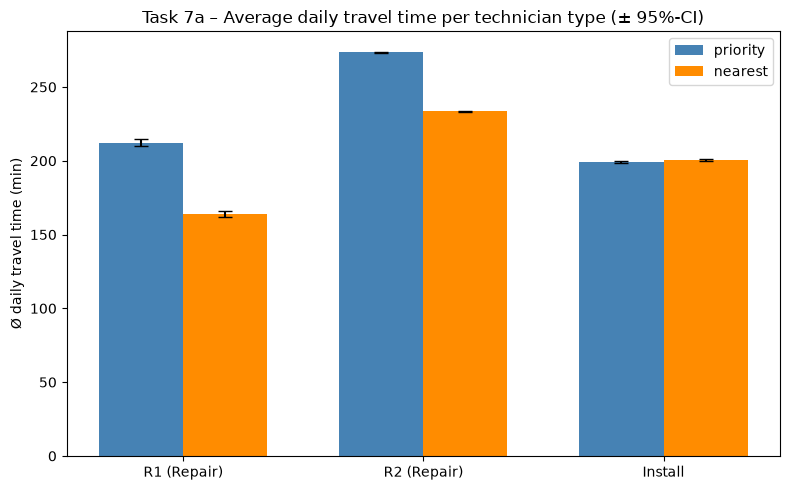

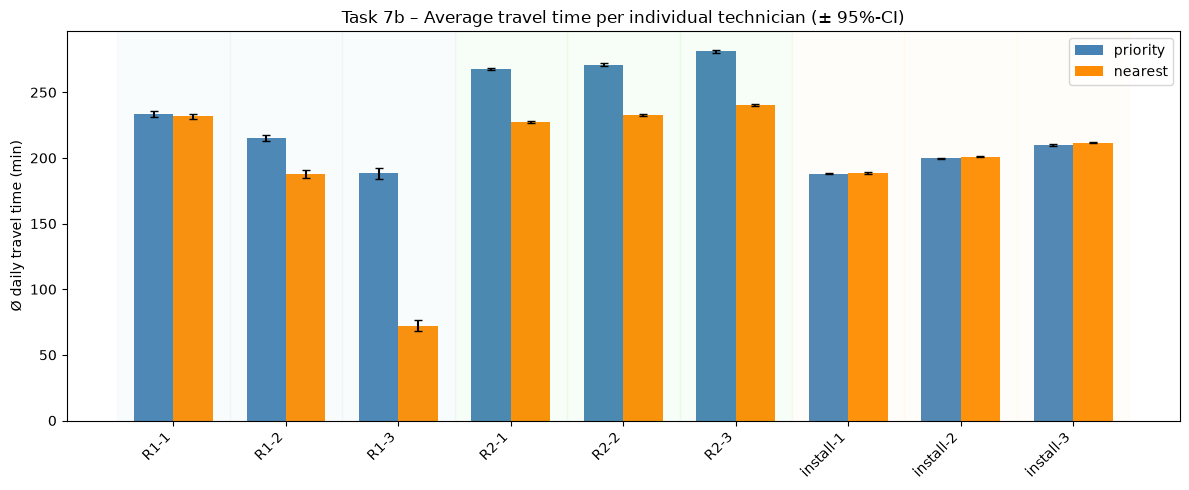

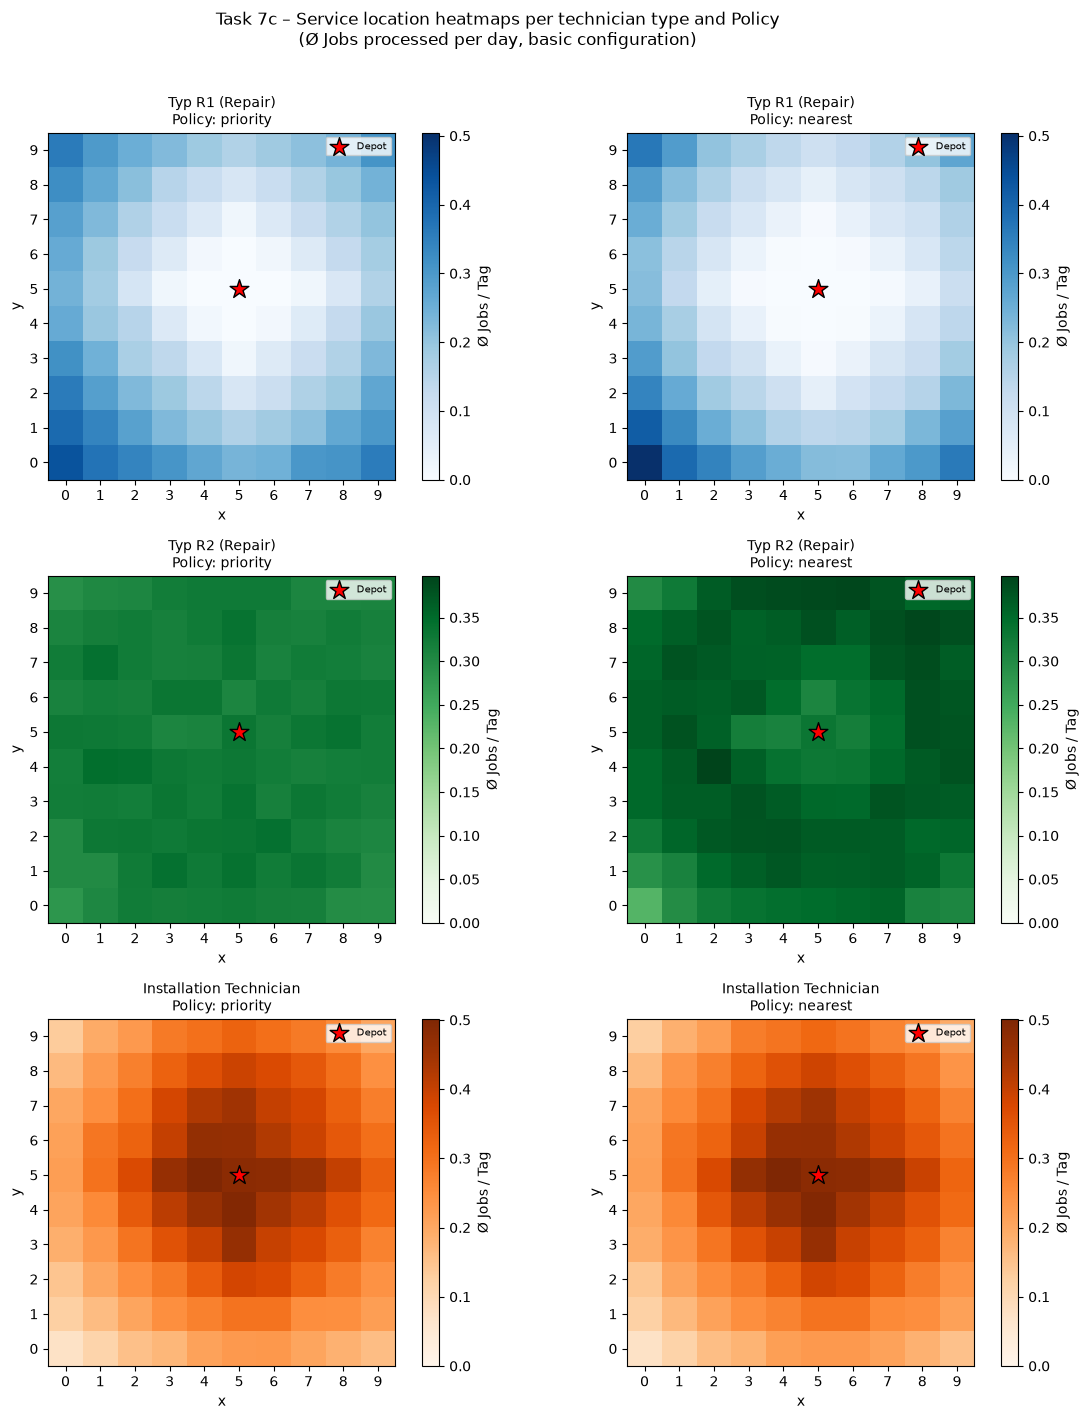


=== Task 7: Average depot-to-job distance per type and policy ===

Policy: PRIORITY
  R1      : 17.88 Jobs/day, Ø Depot-distance = 6.22
  R2      : 32.00 Jobs/day, Ø Depot-distance = 4.96
  install : 30.37 Jobs/day, Ø Depot-distance = 4.34

Policy: NEAREST
  R1      : 14.90 Jobs/day, Ø Depot-distance = 6.49
  R2      : 35.59 Jobs/day, Ø Depot-distance = 4.96
  install : 30.18 Jobs/day, Ø Depot-distance = 4.33



In [35]:
# NEW – Task 7: Avg. daily travel time per technician type + service-location heatmaps

# Data basis: same seeds as Task 2 (base_seed=3000) -> Common Random Numbers.
# tech_day_records contain travel time per technician and day.
# job_records contain the serviced locations. tech_type is derived via a mapping from tech_day_records (no string-parsing of tech_ids needed -> more robust).

# The generated DataFrames are reused in Task 8.
def run_baseline_full(policy, n_reps=N_REPLICATIONS, sim_days=SIM_DAYS,
                      base_seed=3000, warmup_days=WARMUP_DAYS, depot=DEPOT):
    """Runs n_reps replications and returns (df_tech_days, df_jobs) after the warm-up phase. The replication number is stored as a column named 'rep'."""
    tech_rows, job_rows = [], []
    for r in tqdm(range(n_reps), desc=f"Baseline Full ({policy})"):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=R1_SUCCESS_PROB, depot=depot,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()
        tech_rows += [dict(rec, rep=r) for rec in sim.tech_day_records
                      if rec['day'] > warmup_days]
        job_rows  += [dict(rec, rep=r) for rec in sim.job_records
                      if rec['day'] > warmup_days]
    return pd.DataFrame(tech_rows), pd.DataFrame(job_rows)

print("Generating baseline data for Tasks 7 and 8 ...")
baseline_tech_days = {}
baseline_jobs_full = {}
for policy in ('priority', 'nearest'):
    baseline_tech_days[policy], baseline_jobs_full[policy] = run_baseline_full(policy)
    print(f"  {policy}: {len(baseline_tech_days[policy])} technician-days, "
          f"{len(baseline_jobs_full[policy])} job events after warm-up")

# Auxiliary function: derive tech_id -> tech_type from tech_day_records
def get_tech_type_map(df_tech):
    return (df_tech[['tech_id', 'tech_type']]
            .drop_duplicates()
            .set_index('tech_id')['tech_type']
            .to_dict())

# Auxiliary function: ordered technician labeling (R1-1, R1-2, ... R2-1, ...)
def make_tech_order(df_tech):
    type_rank = {'R1': 0, 'R2': 1, 'install': 2}
    df = (df_tech[['tech_id', 'tech_type']]
          .drop_duplicates()
          .assign(type_rank=lambda x: x['tech_type'].map(type_rank))
          .sort_values(['type_rank', 'tech_id'])
          .reset_index(drop=True))
    df['rank'] = df.groupby('tech_type').cumcount() + 1
    df['label'] = df['tech_type'] + '-' + df['rank'].astype(str)
    return df  # columns: tech_id, tech_type, type_rank, rank, label

# Technician sequence from the priority policy (the same for both, given identical staffing)
tech_order_df = make_tech_order(baseline_tech_days['priority'])
TECH_ORDER_IDS    = tech_order_df['tech_id'].tolist()
TECH_ORDER_LABELS = tech_order_df['label'].tolist()
TECH_ORDER_TYPES  = tech_order_df['tech_type'].tolist()
TYPE_COLORS       = {'R1': 'lightblue', 'R2': 'lightgreen', 'install': 'moccasin'}

# 7a) Average daily travel time per technician type (PDF KPI) with 95% CI
print("\n=== Task 7a: Average daily travel time per technician type ===\n")
travel_type_rows = []
for policy in ('priority', 'nearest'):
    df = baseline_tech_days[policy]
    # Mean travel time per (replication, technician type) -> CI across replications
    per_rep = df.groupby(['rep', 'tech_type'])['travel_time'].mean().reset_index()
    for ttype, grp in per_rep.groupby('tech_type'):
        data = grp['travel_time'].values
        m, hw = data.mean(), ci_half_width(data)
        travel_type_rows.append({'policy': policy, 'tech_type': ttype,
                                  'mean_min': round(m, 1), 'ci_hw': round(hw, 1)})
        print(f"  {policy:9s} | {ttype:8s}: {m:.1f} min  "
              f"95%-CI [{m-hw:.1f}, {m+hw:.1f}]")

df_travel_type = pd.DataFrame(travel_type_rows)

fig, ax = plt.subplots(figsize=(8, 5))
type_order = ['R1', 'R2', 'install']
x = np.arange(len(type_order))
width = 0.35
for i, (policy, color) in enumerate(zip(('priority', 'nearest'),
                                         ('steelblue', 'darkorange'))):
    sub = (df_travel_type[df_travel_type['policy'] == policy]
           .set_index('tech_type')
           .reindex(type_order))
    ax.bar(x + (i - 0.5) * width, sub['mean_min'], width,
           yerr=sub['ci_hw'], capsize=5, label=policy, color=color)
ax.set_xticks(x)
ax.set_xticklabels(['R1 (Repair)', 'R2 (Repair)', 'Install'])
ax.set_ylabel('Ø daily travel time (min)')
ax.set_title('Task 7a – Average daily travel time per technician type (± 95%-CI)')
ax.legend()
plt.tight_layout()
plt.show()

# 7b) Average daily travel time per individual technician (detailed analysis)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(TECH_ORDER_IDS))
width = 0.35
for i, (policy, color) in enumerate(zip(('priority', 'nearest'),
                                         ('steelblue', 'darkorange'))):
    df = baseline_tech_days[policy]
    per_rep = df.groupby(['rep', 'tech_id'])['travel_time'].mean().reset_index()
    agg = (per_rep.groupby('tech_id')['travel_time']
           .agg(mean='mean', ci_hw=lambda v: ci_half_width(v.values))
           .reindex(TECH_ORDER_IDS))
    ax.bar(x + (i - 0.5) * width, agg['mean'], width,
           yerr=agg['ci_hw'], capsize=3, label=policy, color=color)

# Background colors by technician type
for idx, ttype in enumerate(TECH_ORDER_TYPES):
    ax.axvspan(idx - 0.5, idx + 0.5,
               alpha=0.07, color=TYPE_COLORS[ttype])
ax.set_xticks(x)
ax.set_xticklabels(TECH_ORDER_LABELS, rotation=45, ha='right')
ax.set_ylabel('Ø daily travel time (min)')
ax.set_title('Task 7b – Average travel time per individual technician (± 95%-CI)')
ax.legend()
plt.tight_layout()
plt.show()

# 7c) Service location heatmaps by technician type and policy
# Only actual customer visits count: completed + failed_first_attempt
SERVED_STATUS = ('completed', 'failed_first_attempt')
EVAL_DAYS = EVAL_HORIZON_DAYS  # Normalization basis

def build_service_grid(df_jobs, df_tech, tech_type_filter):
    """10×10 Heatmap: Average jobs served per day at each grid point."""
    type_map = get_tech_type_map(df_tech)
    served = df_jobs[df_jobs['status'].isin(SERVED_STATUS)].copy()
    served['tech_type'] = served['tech_id'].map(type_map)
    sub = served[served['tech_type'] == tech_type_filter]
    grid = np.zeros((GRID_SIZE, GRID_SIZE))
    for loc, cnt in sub['location'].value_counts().items():
        grid[loc[1], loc[0]] += cnt
    return grid / (N_REPLICATIONS * EVAL_DAYS)

HEATMAP_TYPES = [
    ('R1',      'Typ R1 (Repair)',       'Blues'),
    ('R2',      'Typ R2 (Repair)',       'Greens'),
    ('install', 'Installation Technician',     'Oranges'),
]

depot_x, depot_y = DEPOT
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for row_idx, (ttype, ttype_label, cmap) in enumerate(HEATMAP_TYPES):
    grids = {p: build_service_grid(baseline_jobs_full[p],
                                    baseline_tech_days[p], ttype)
             for p in ('priority', 'nearest')}
    vmax = max(g.max() for g in grids.values())

    for col_idx, policy in enumerate(('priority', 'nearest')):
        ax = axes[row_idx, col_idx]
        im = ax.imshow(grids[policy], origin='lower', cmap=cmap,
                       vmin=0, vmax=vmax, aspect='equal')
        plt.colorbar(im, ax=ax, fraction=0.046, label='Ø Jobs / Tag')
        ax.scatter(depot_x, depot_y, marker='*', s=200,
                   color='red', edgecolors='black', zorder=5, label='Depot')
        ax.set_title(f'{ttype_label}\nPolicy: {policy}', fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.set_xticks(range(GRID_SIZE))
        ax.set_yticks(range(GRID_SIZE))
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Task 7c – Service location heatmaps per technician type and Policy\n'
             '(Ø Jobs processed per day, basic configuration)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# 7d) Automatic interpretation: Depot-to-job distance
print("\n=== Task 7: Average depot-to-job distance per type and policy ===\n")
for policy in ('priority', 'nearest'):
    df_jobs = baseline_jobs_full[policy].copy()
    type_map = get_tech_type_map(baseline_tech_days[policy])
    df_jobs['tech_type'] = df_jobs['tech_id'].map(type_map)
    df_jobs['dist_depot'] = df_jobs['location'].apply(
        lambda loc: manhattan(loc, DEPOT))
    served = df_jobs[df_jobs['status'].isin(SERVED_STATUS)]
    print(f"Policy: {policy.upper()}")
    for ttype, _ , _ in HEATMAP_TYPES:
        sub = served[served['tech_type'] == ttype]
        n_per_day = len(sub) / (N_REPLICATIONS * EVAL_DAYS)
        avg_dist  = sub['dist_depot'].mean()
        print(f"  {ttype:8s}: {n_per_day:.2f} Jobs/day, "
              f"Ø Depot-distance = {avg_dist:.2f}")
    print()

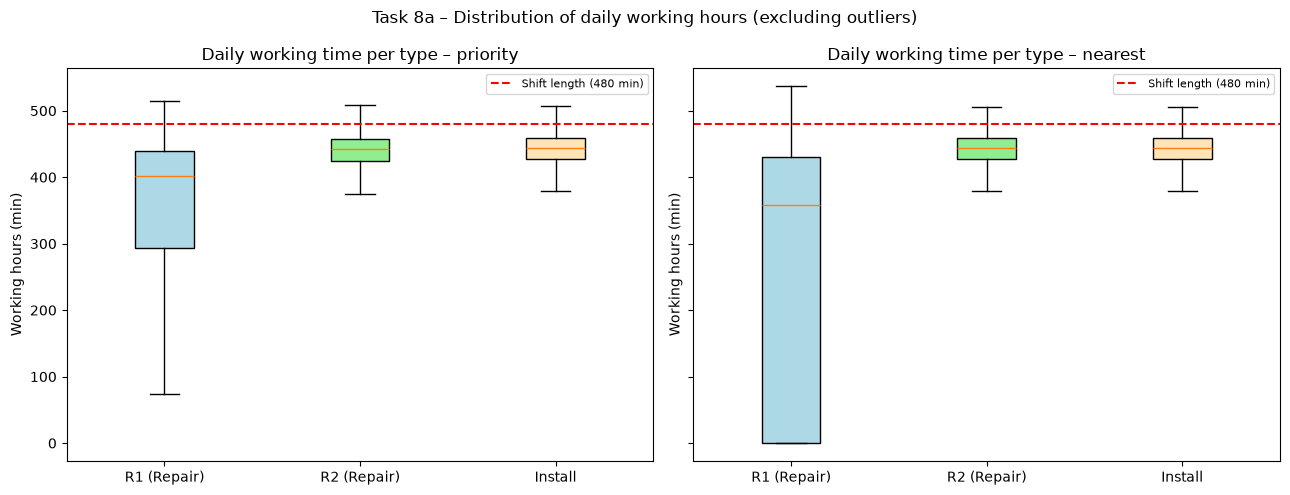

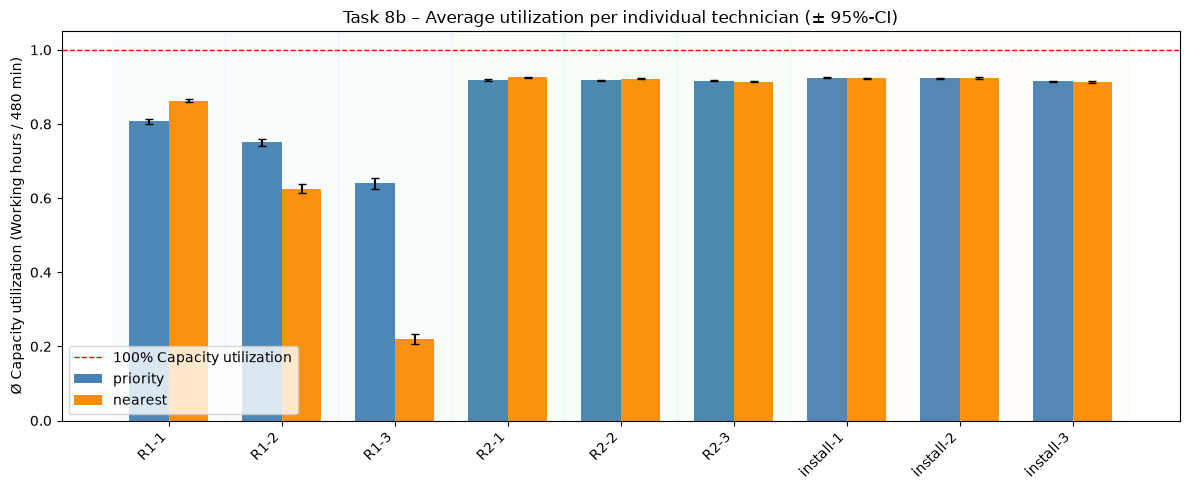

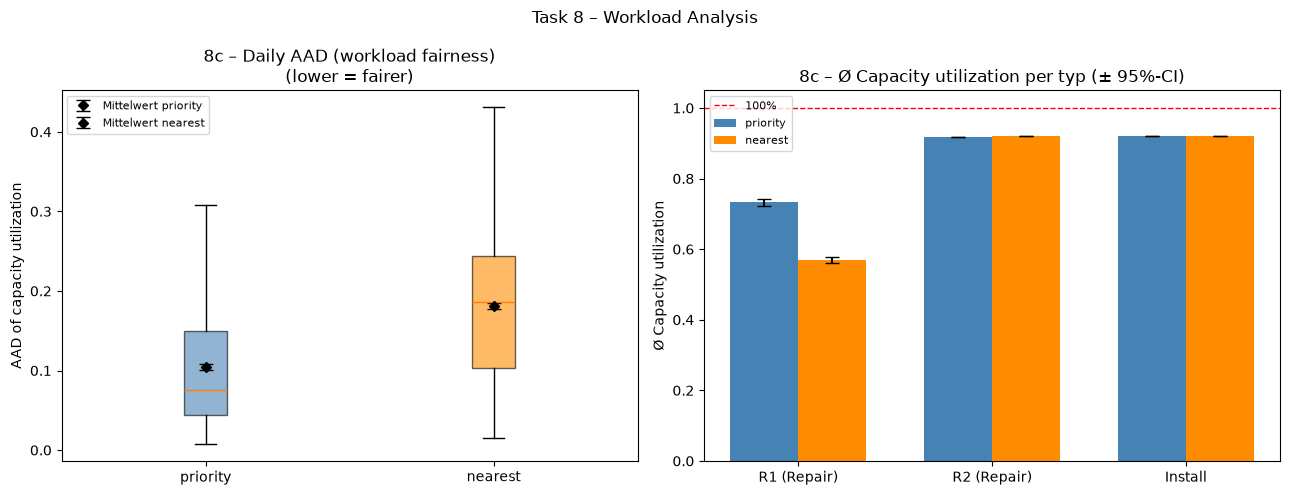

Task 8 – Working time / Overtime / Idle time per technician type:


,policy,tech_type,mean_working_min,mean_utilization,overtime_days_%,mean_overtime_min,idle_days_%
3,nearest,R1,273.3,0.569,2.2,0.2,26.2
4,nearest,R2,442.1,0.921,4.0,0.3,0.0
5,nearest,install,441.7,0.920,3.8,0.3,0.0
0,priority,R1,351.6,0.733,1.9,0.2,5.0
1,priority,R2,440.6,0.918,4.3,0.4,0.0
2,priority,install,442.2,0.921,4.2,0.3,0.0



=== Task 8: Workload Fairness (AAD) – Summary ===

  priority : mittlere AAD = 0.1047  95%-CI [0.1013, 0.1082]
  nearest  : mittlere AAD = 0.1816  95%-CI [0.1779, 0.1853]

  -> priority is fairer (lower AAD, difference: 42.4%)


In [39]:
# NEW – Task 8: Daily working hours and workload fairness (AAD)

# Data basis: baseline_tech_days from Task 7 (same seeds, base_seed=3000).
# Utilization u = working time / 480 min; overtime is included -> u > 1 is possible (consistent with PDF).
# Workload fairness according to PDF: AAD_t = (1/K) * Σ_i |u_it − mean_u_t| per day t, then averaged over all evaluation days.

# Calculate utilization
for policy in ('priority', 'nearest'):
    baseline_tech_days[policy]['utilization'] = (
        baseline_tech_days[policy]['working_time'] / MINUTES_PER_DAY
    )

# 8a) Distribution of daily working hours by technician type
TYPE_ORDER = ['R1', 'R2', 'install']
TYPE_LABELS = ['R1 (Repair)', 'R2 (Repair)', 'Install']

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, policy in zip(axes, ('priority', 'nearest')):
    df = baseline_tech_days[policy]
    data = [df[df['tech_type'] == t]['working_time'].values for t in TYPE_ORDER]
    bp = ax.boxplot(data, tick_labels=TYPE_LABELS, patch_artist=True, showfliers=False)
    for patch, ttype in zip(bp['boxes'], TYPE_ORDER):
        patch.set_facecolor(TYPE_COLORS[ttype])
    ax.axhline(MINUTES_PER_DAY, color='red', linestyle='--',
               linewidth=1.5, label='Shift length (480 min)')
    ax.set_title(f'Daily working time per type – {policy}')
    ax.set_ylabel('Working hours (min)')
    ax.legend(fontsize=8)
plt.suptitle('Task 8a – Distribution of daily working hours (excluding outliers)',
             fontsize=12)
plt.tight_layout()
plt.show()

# 8b) Ø Utilization per individual technician
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(TECH_ORDER_IDS))
width = 0.35
for i, (policy, color) in enumerate(zip(('priority', 'nearest'),
                                         ('steelblue', 'darkorange'))):
    df = baseline_tech_days[policy]
    per_rep = df.groupby(['rep', 'tech_id'])['utilization'].mean().reset_index()
    agg = (per_rep.groupby('tech_id')['utilization']
           .agg(mean='mean', ci_hw=lambda v: ci_half_width(v.values))
           .reindex(TECH_ORDER_IDS))
    ax.bar(x + (i - 0.5) * width, agg['mean'], width,
           yerr=agg['ci_hw'], capsize=3, label=policy, color=color)

for idx, ttype in enumerate(TECH_ORDER_TYPES):
    ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.07, color=TYPE_COLORS[ttype])
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='100% Capacity utilization')
ax.set_xticks(x)
ax.set_xticklabels(TECH_ORDER_LABELS, rotation=45, ha='right')
ax.set_ylabel('Ø Capacity utilization (Working hours / 480 min)')
ax.set_title('Task 8b – Average utilization per individual technician (± 95%-CI)')
ax.legend()
plt.tight_layout()
plt.show()

# 8c) Workload Fairness: AAD based on average daily utilization
def compute_daily_aad(df):
    """Calculates AAD per (rep, day): mean absolute deviation from the daily mean."""
    return (df.groupby(['rep', 'day'])['utilization']
              .apply(lambda g: (g - g.mean()).abs().mean())
              .reset_index(name='aad'))

aad_summary = {}
aad_box_data = []
for policy in ('priority', 'nearest'):
    df_aad = compute_daily_aad(baseline_tech_days[policy])
    # Mean AAD per replication -> CI across replications
    per_rep_aad = df_aad.groupby('rep')['aad'].mean()
    m, hw = per_rep_aad.mean(), ci_half_width(per_rep_aad.values)
    aad_summary[policy] = {'mean': m, 'hw': hw, 'per_rep': per_rep_aad.values}
    aad_box_data.append(df_aad['aad'].values)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot of daily AAD
ax = axes[0]
bp = ax.boxplot(aad_box_data, tick_labels=['priority', 'nearest'],
                patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ['steelblue', 'darkorange']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
for i, policy in enumerate(['priority', 'nearest']):
    m, hw = aad_summary[policy]['mean'], aad_summary[policy]['hw']
    ax.errorbar(i + 1, m, yerr=hw, fmt='D', color='black',
                capsize=5, markersize=5, label=f'Mittelwert {policy}')
ax.set_ylabel('AAD of capacity utilization')
ax.set_title('8c – Daily AAD (workload fairness)\n(lower = fairer)')
ax.legend(fontsize=8)

# Ø Auslastung je Typ als Vergleich
ax2 = axes[1]
x = np.arange(len(TYPE_ORDER))
width = 0.35
for i, (policy, color) in enumerate(zip(('priority', 'nearest'),
                                         ('steelblue', 'darkorange'))):
    df = baseline_tech_days[policy]
    per_rep = df.groupby(['rep', 'tech_type'])['utilization'].mean().reset_index()
    agg = (per_rep.groupby('tech_type')['utilization']
           .agg(mean='mean', ci_hw=lambda v: ci_half_width(v.values))
           .reindex(TYPE_ORDER))
    ax2.bar(x + (i - 0.5) * width, agg['mean'], width,
            yerr=agg['ci_hw'], capsize=5, label=policy, color=color)
ax2.axhline(1.0, color='red', linestyle='--', linewidth=1, label='100%')
ax2.set_xticks(x)
ax2.set_xticklabels(TYPE_LABELS)
ax2.set_ylabel('Ø Capacity utilization')
ax2.set_title('8c – Ø Capacity utilization per typ (± 95%-CI)')
ax2.legend(fontsize=8)

plt.suptitle('Task 8 – Workload Analysis', fontsize=12)
plt.tight_layout()
plt.show()

# 8d) Summary Table: Working Hours, Capacity Utilization, Overtime
rows_wt = []
for policy in ('priority', 'nearest'):
    df = baseline_tech_days[policy]
    for ttype, grp in df.groupby('tech_type'):
        rows_wt.append({
            'policy':            policy,
            'tech_type':         ttype,
            'mean_working_min':  round(grp['working_time'].mean(), 1),
            'mean_utilization':  round(grp['utilization'].mean(), 3),
            'overtime_days_%':   round((grp['overtime'] > 0).mean() * 100, 1),
            'mean_overtime_min': round(grp['overtime'].mean(), 1),
            'idle_days_%':       round((grp['working_time'] == 0).mean() * 100, 1),
        })
print("Task 8 – Working time / Overtime / Idle time per technician type:")
display(pd.DataFrame(rows_wt).sort_values(['policy', 'tech_type']))

# 8e) Automatic interpretation
print("\n=== Task 8: Workload Fairness (AAD) – Summary ===\n")
for policy in ('priority', 'nearest'):
    m, hw = aad_summary[policy]['mean'], aad_summary[policy]['hw']
    print(f"  {policy:9s}: mittlere AAD = {m:.4f}  "
          f"95%-CI [{m-hw:.4f}, {m+hw:.4f}]")

pri_aad = aad_summary['priority']['mean']
nea_aad = aad_summary['nearest']['mean']
fairer_policy = 'priority' if pri_aad < nea_aad else 'nearest'
diff_pct = abs(pri_aad - nea_aad) / max(pri_aad, nea_aad) * 100
print(f"\n  -> {fairer_policy} is fairer "
      f"(lower AAD, difference: {diff_pct:.1f}%)")

Ø Manhattan distance depot -> customers: (5,5) = 5.00, (3,3) = 5.40

Simulate both portfolio scenarios for both policies ...


Depot-Szenarien (priority):   0%|          | 0/2 [00:00<?, ?it/s]

Depot-Szenarien (nearest):   0%|          | 0/2 [00:00<?, ?it/s]


KPI-Comparison: Depot (5,5) vs. Depot (3,3):


,KPI,"priority | Depot (5,5) (mean)","priority | Depot (5,5) (±CI)","priority | Depot (3,3) (mean)","priority | Depot (3,3) (±CI)","nearest | Depot (5,5) (mean)","nearest | Depot (5,5) (±CI)","nearest | Depot (3,3) (mean)","nearest | Depot (3,3) (±CI)"
0,Avg. service score Z_d,3.0508,0.3490,6.1610,0.8596,3.3852,0.2247,5.1095,0.3483
1,First-time fix rate,0.9917,0.0009,0.9868,0.0012,0.9782,0.0010,0.9774,0.0007
2,P(failed first attempt),0.0083,0.0009,0.0132,0.0012,0.0218,0.0010,0.0226,0.0007
3,Utilization R1,0.7325,0.0090,0.8052,0.0071,0.5694,0.0084,0.6369,0.0072
4,Utilization R2,0.9180,0.0011,0.9218,0.0008,0.9211,0.0008,0.9228,0.0008
5,Utilization Install,0.9212,0.0009,0.9207,0.0009,0.9202,0.0009,0.9193,0.0008
6,Avg. travel time R1 (min),212.1927,2.4254,239.4731,2.0595,163.8847,2.1094,185.6472,1.8358
7,Avg. travel time R2 (min),273.4034,0.5784,277.6524,0.5708,233.5233,0.5242,241.3553,0.5161
8,Avg. travel time Install (min),199.3110,0.5207,200.4577,0.6590,200.4243,0.4900,203.1555,0.3625
9,Workload AAD,0.1047,0.0034,0.0784,0.0028,0.1816,0.0037,0.1541,0.0031



=== Task 9: Paired t-test Z_d ===

Policy: PRIORITY
  Z_d Depot (5,5):     3.051
  Z_d Depot (3,3):     6.161
  Difference (new-old): +3.110  95%-CI [+2.514, +3.707]
  Relative change:   +102.0%
  t=10.91, p=0.0000 -> Significant (p<0.05)
  Bewertung: Baseline staffing level NOT adequate at the new location

Policy: NEAREST
  Z_d Depot (5,5):     3.385
  Z_d Depot (3,3):     5.110
  Difference (new-old): +1.724  95%-CI [+1.364, +2.085]
  Relative change:   +50.9%
  t=10.00, p=0.0000 -> Significant (p<0.05)
  Bewertung: Baseline staffing level NOT adequate at the new location



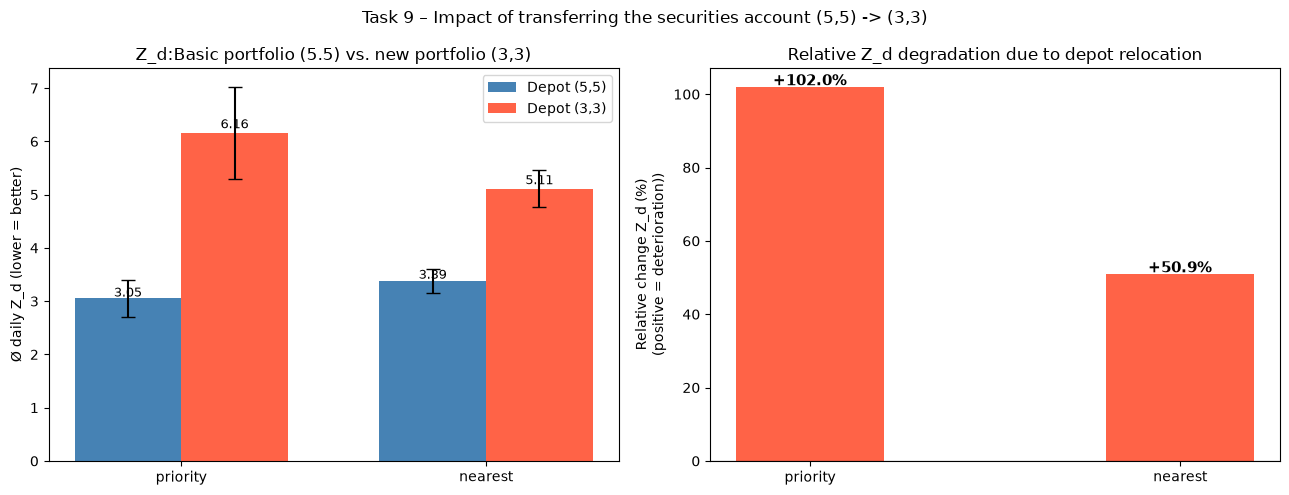


=== Task 9: Summary and Evaluation ===

Background: Average portfolio distance increases from 5.00 on 5.40 Units (+8.0%).
Longer trip legs mean fewer reachable jobs per shift.

Policy PRIORITY: Z_d rises from 3.051 on 6.161 (+102.0%), p=0.0000 -> significant.
  -> The baseline staffing level (3/3/3) is NOT adequate at the new location.
     Recommendation: Results from task 4 (Factory Staffing) use to select the most effective personnel expansion.

Policy NEAREST: Z_d rises from 3.385 on 5.110 (+50.9%), p=0.0000 -> significant.
  -> The baseline staffing level (3/3/3) is NOT adequate at the new location.
     Recommendation: Results from task 4 (Factory Staffing) use to select the most effective personnel expansion.



In [40]:
# NEW – Task 9: Depot relocation (5,5) -> (3,3)
# Question: Does the baseline staffing level (3/3/3) remain adequate at the new location?
# Methodology: Common Random Numbers (same seeds, base_seed=3000, as in Task 2) -> allows for a paired t-test on Z_d per replication.
# Background: Depot (3,3) is off-center -> mean Manhattan distance to uniformly distributed customers increases from E[d|(5,5)] ≈ 3.33 to E[d|(3,3)] ≈ 4.27 -> longer trips, fewer jobs completable per day.

DEPOT_NEW    = (3, 3)
DEPOT_OLD    = DEPOT   # (5, 5) from the parameters

# Calculate mean Manhattan distance (analytically)
all_locs = [(x, y) for x in range(GRID_SIZE) for y in range(GRID_SIZE)]
mean_dist_old = np.mean([manhattan(loc, DEPOT_OLD) for loc in all_locs])
mean_dist_new = np.mean([manhattan(loc, DEPOT_NEW) for loc in all_locs])
print(f"Ø Manhattan distance depot -> customers: "
      f"(5,5) = {mean_dist_old:.2f}, (3,3) = {mean_dist_new:.2f}\n")

def run_kpi_replications_depot(policy, depot, n_reps=N_REPLICATIONS,
                                sim_days=SIM_DAYS, base_seed=3000):
    """Same as Task 2, but with a freely selectable depot. Identical seeds -> Common Random Numbers for pairwise comparison."""
    all_kpis = []
    for r in range(n_reps):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=R1_SUCCESS_PROB, depot=depot,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()
        all_kpis.append(compute_kpis_for_sim(sim))
    return pd.DataFrame(all_kpis)

print("Simulate both portfolio scenarios for both policies ...")
DEPOT_SCENARIOS = [('Depot (5,5)', DEPOT_OLD), ('Depot (3,3)', DEPOT_NEW)]
depot_kpis = {}
for policy in ('priority', 'nearest'):
    for depot_label, depot in tqdm(DEPOT_SCENARIOS, desc=f"Depot-Szenarien ({policy})"):
        depot_kpis[(policy, depot_label)] = run_kpi_replications_depot(policy, depot)

# 9a) KPI Comparison Table
KPI_LABELS_T9 = [
    ('avg_Zd',               'Avg. service score Z_d'),
    ('first_time_fix_rate',  'First-time fix rate'),
    ('prob_failed_first_attempt', 'P(failed first attempt)'),
    ('util_R1',              'Utilization R1'),
    ('util_R2',              'Utilization R2'),
    ('util_install',         'Utilization Install'),
    ('avg_travel_R1',        'Avg. travel time R1 (min)'),
    ('avg_travel_R2',        'Avg. travel time R2 (min)'),
    ('avg_travel_install',   'Avg. travel time Install (min)'),
    ('workload_aad',         'Workload AAD'),
    ('avg_waiting_days',     'Avg. waiting time (days)'),
]

rows_t9 = []
for kpi_col, kpi_label in KPI_LABELS_T9:
    row = {'KPI': kpi_label}
    for policy in ('priority', 'nearest'):
        for label, _ in DEPOT_SCENARIOS:
            data = depot_kpis[(policy, label)][kpi_col].dropna().values
            m, hw = data.mean(), ci_half_width(data)
            col = f'{policy} | {label}'
            row[col + ' (mean)'] = round(m, 4)
            row[col + ' (±CI)']  = round(hw, 4)
    rows_t9.append(row)

print("\nKPI-Comparison: Depot (5,5) vs. Depot (3,3):")
display(pd.DataFrame(rows_t9))

# 9b) pairwise t-test for Z D
print("\n=== Task 9: Paired t-test Z_d ===\n")
test_results = {}
for policy in ('priority', 'nearest'):
    zd_old = depot_kpis[(policy, 'Depot (5,5)')]['avg_Zd'].values
    zd_new = depot_kpis[(policy, 'Depot (3,3)')]['avg_Zd'].values
    diff   = zd_new - zd_old
    m_diff = diff.mean()
    hw     = ci_half_width(diff)
    t_stat, p_val = stats.ttest_rel(zd_new, zd_old)
    rel_pct = m_diff / zd_old.mean() * 100
    significant = p_val < 0.05 and m_diff > 0
    test_results[policy] = {
        'zd_old': zd_old.mean(), 'zd_new': zd_new.mean(),
        'diff': m_diff, 'hw': hw, 'rel_pct': rel_pct,
        't': t_stat, 'p': p_val, 'significant': significant
    }
    print(f"Policy: {policy.upper()}")
    print(f"  Z_d Depot (5,5):     {zd_old.mean():.3f}")
    print(f"  Z_d Depot (3,3):     {zd_new.mean():.3f}")
    print(f"  Difference (new-old): {m_diff:+.3f}  95%-CI [{m_diff-hw:+.3f}, {m_diff+hw:+.3f}]")
    print(f"  Relative change:   {rel_pct:+.1f}%")
    print(f"  t={t_stat:.2f}, p={p_val:.4f} "
          f"-> {'Significant (p<0.05)' if p_val < 0.05 else 'not significant'}")
    verdict = ("Baseline staffing level NOT adequate at the new location"
               if significant else
               "Baseline staffing remains adequate.")
    print(f"  Bewertung: {verdict}\n")

# 9c) Visualization: Z_d comparison (both depots, both policies)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Z_d Bar chart
ax = axes[0]
x = np.arange(2)
width = 0.35
for i, (label, color) in enumerate(zip(['Depot (5,5)', 'Depot (3,3)'],
                                        ['steelblue', 'tomato'])):
    means = [depot_kpis[(p, label)]['avg_Zd'].mean()
             for p in ('priority', 'nearest')]
    hws   = [ci_half_width(depot_kpis[(p, label)]['avg_Zd'].values)
             for p in ('priority', 'nearest')]
    bars = ax.bar(x + (i - 0.5) * width, means, width,
                  yerr=hws, capsize=5, label=label, color=color)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(hws) * 0.1,
                f'{m:.2f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['priority', 'nearest'])
ax.set_ylabel('Ø daily Z_d (lower = better)')
ax.set_title('Z_d:Basic portfolio (5.5) vs. new portfolio (3,3)')
ax.legend()

# Plot 2: Relative deterioration (%) per policy
ax2 = axes[1]
policies_list = ['priority', 'nearest']
rel_changes = [test_results[p]['rel_pct'] for p in policies_list]
colors_bar = ['tomato' if r > 0 else 'steelblue' for r in rel_changes]
bars2 = ax2.bar(policies_list, rel_changes, color=colors_bar, width=0.4)
ax2.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars2, rel_changes):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             val + 0.5 * np.sign(val),
             f'{val:+.1f}%', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Relative change Z_d (%)\n(positive = deterioration))')
ax2.set_title('Relative Z_d degradation due to depot relocation')

plt.suptitle('Task 9 – Impact of transferring the securities account (5,5) -> (3,3)', fontsize=12)
plt.tight_layout()
plt.show()

# 9d) Automatic interpretation (no hard-coded numbers)
print("\n=== Task 9: Summary and Evaluation ===\n")
print(f"Background: Average portfolio distance increases from {mean_dist_old:.2f} "
      f"on {mean_dist_new:.2f} Units (+{(mean_dist_new/mean_dist_old-1)*100:.1f}%).")
print(f"Longer trip legs mean fewer reachable jobs per shift.\n")
for policy in ('priority', 'nearest'):
    r = test_results[policy]
    print(f"Policy {policy.upper()}: Z_d rises from {r['zd_old']:.3f} on "
          f"{r['zd_new']:.3f} ({r['rel_pct']:+.1f}%), "
          f"p={r['p']:.4f} -> "
          f"{'significant' if r['p']<0.05 else 'not significant'}.")
    if r['significant']:
        print(f"  -> The baseline staffing level (3/3/3) is NOT adequate at the new location.")
        print(f"     Recommendation: Results from task 4 (Factory Staffing) "
              f"use to select the most effective personnel expansion.")
    else:
        print(f"  -> Baseline staffing remains adequate.")
    print()

=== Task 10a: KPI Comparison – Baseline (Tasks 2/3) ===



,KPI,Direction,priority (mean ± CI),nearest (mean ± CI),Winner (Baseline),Significant?
0,Avg. Service Score Z_d,lower,3.051 ± 0.349,3.385 ± 0.225,priority,~
1,First-time Fix Rate,higher,0.992 ± 0.001,0.978 ± 0.001,priority,✓
2,P(failed first attempt),lower,0.008 ± 0.001,0.022 ± 0.001,priority,✓
3,Avg. Travel Time R1 (min),lower,212.193 ± 2.425,163.885 ± 2.109,nearest,✓
4,Avg. Travel Time R2 (min),lower,273.403 ± 0.578,233.523 ± 0.524,nearest,✓
5,Avg. Travel Time Install (min),lower,199.311 ± 0.521,200.424 ± 0.490,priority,✓
6,Utilization R1,higher,0.733 ± 0.009,0.569 ± 0.008,priority,✓
7,Utilization R2,higher,0.918 ± 0.001,0.921 ± 0.001,nearest,✓
8,Utilization Install,higher,0.921 ± 0.001,0.920 ± 0.001,priority,~
9,Workload Balance (AAD),lower,0.105 ± 0.003,0.182 ± 0.004,priority,✓



Baseline-Wins: priority=7, nearest=4

=== Task 10b: Analysis of conditions (Task 5 – 3^3 Factorial) ===

Scenario wins per arrival rate (out of 9 combinations each):


winner,nearest,priority
arrival_rate,,
60,0,9
80,4,5
100,6,3



Detailed winner matrix (negative delta = better priority):


arrival_rate               60       80       100
travel_label r1_success                         
adverse      0.80       -1.292  119.661 -118.584
             0.90       -0.605  105.094 -128.833
             0.95       -0.202   86.767 -131.804
baseline     0.80       -0.609   -2.075   49.473
             0.90       -0.320   -0.082   67.478
             0.95       -0.170    0.515   77.622
favorable    0.80       -0.211   -2.258   16.829
             0.90       -0.167   -1.136    7.557
             0.95       -0.138   -0.560    6.003

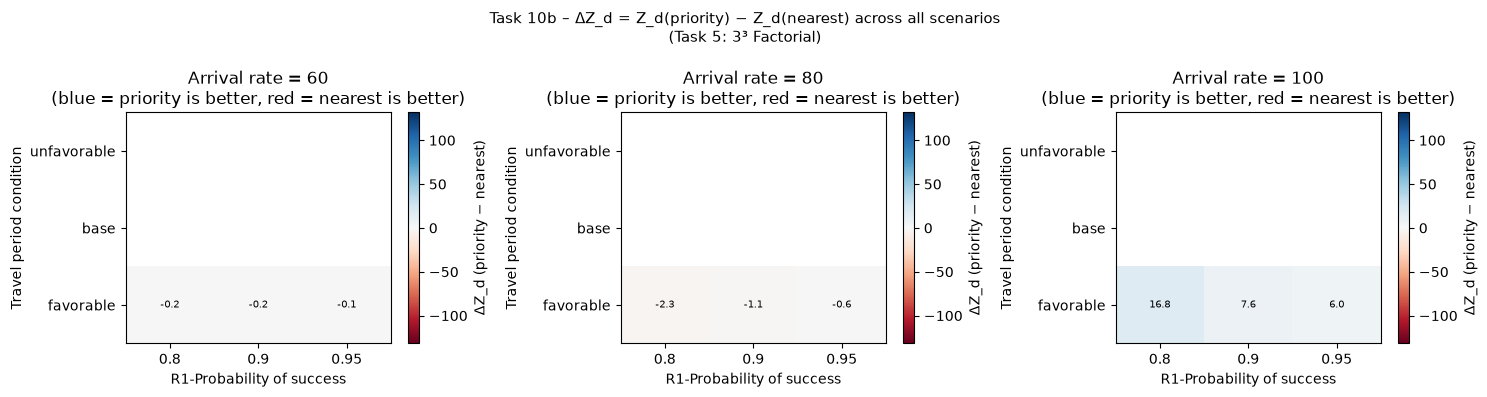


=== Task 10c: Robustness regarding depot relocation (Task 9) ===

  priority : Z_d 3.051 → 6.161 (+102.0%)  p=0.0000 (significant)
  nearest  : Z_d 3.385 → 5.110 (+50.9%)  p=0.0000 (significant)

  -> nearest shows a smaller relative deterioration upon portfolio transfer (more robust).


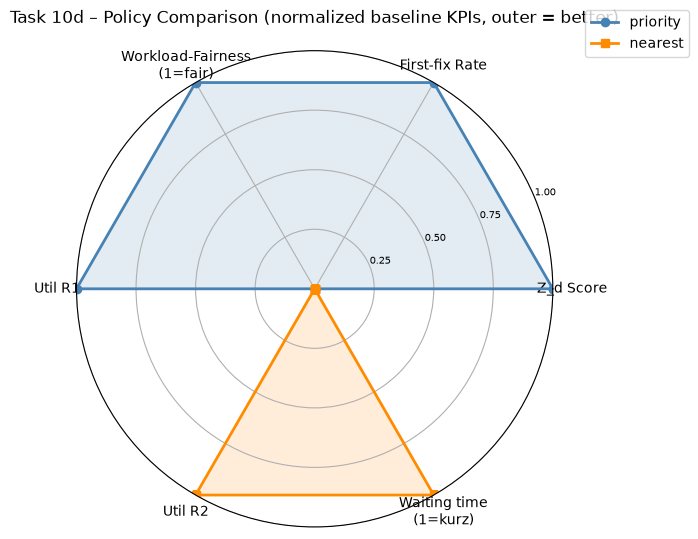


=== Task 10e: Decision Matrix ===



,Anzahl_Szenarien,Ø_Vorteil
Recommended policy,,
nearest,10,53.70
priority,17,22.88



Conditions under which PRIORITY is better:
  Arrival rate: [np.int64(60), np.int64(80), np.int64(100)]
  Travel time:     ['favorable', 'baseline', 'adverse']
  R1-Success:     [np.float64(0.8), np.float64(0.9), np.float64(0.95)]

Conditions under which NEAREST is better:
  Arrival rate: [np.int64(80), np.int64(100)]
  Travel time:     ['baseline', 'adverse', 'favorable']
  R1-Success:     [np.float64(0.8), np.float64(0.9), np.float64(0.95)]

TASK 10f – RECOMMENDATION FOR ACTION FOR THE DISPATCHING MANAGER

SUMMARY OF RESULTS:
  Baseline performance (Task 2):
   - priority wins on 7/11 KPIs
   - nearest wins on 4/11 KPIs
   -> Overall baseline winner: PRIORITY

  Service score Z_d:
   - priority: 3.051 ± 0.349
   - nearest: 3.385 ± 0.225

  Factorial experiment (Task 5): 27 scenarios
   - priority better in: 17/27 scenarios
   - nearest better in: 10/27 scenarios

  Workload fairness (Task 8):
   - priority AAD: 0.1047
   - nearest AAD: 0.1816
   -> priority is fairer

  Robustness re

In [48]:
# NEW – Task 10: Managerial Implications and Policy Recommendations

# Synthesis of all results from Tasks 2–9.
# No new simulation runs – only aggregation of previously calculated data.
# Structure:
#   10a) Overall KPI comparison (Baseline, Task 2)
#   10b) Analysis of conditions (Task 5: which policy wins under what circumstances?)
#   10c) Robustness (Task 9: depot relocation)
#   10d) Radar chart: visual policy comparison
#   10e) Decision matrix (when to recommend which policy)
#   10f) Structured recommendations for action

# 10a) Overall KPI Comparison – Baseline (from Task 2: kpi_results)
KPI_DISPLAY = [
    ('avg_Zd',                    'Avg. Service Score Z_d',           'lower'),
    ('first_time_fix_rate',       'First-time Fix Rate',              'higher'),
    ('prob_failed_first_attempt', 'P(failed first attempt)',          'lower'),
    ('avg_travel_R1',             'Avg. Travel Time R1 (min)',        'lower'),
    ('avg_travel_R2',             'Avg. Travel Time R2 (min)',        'lower'),
    ('avg_travel_install',        'Avg. Travel Time Install (min)',   'lower'),
    ('util_R1',                   'Utilization R1',                   'higher'),
    ('util_R2',                   'Utilization R2',                   'higher'),
    ('util_install',              'Utilization Install',              'higher'),
    ('workload_aad',              'Workload Balance (AAD)',           'lower'),
    ('avg_waiting_days',          'Avg. Waiting Time (days)',         'lower'),
]

baseline_rows = []
for kpi_col, kpi_label, direction in KPI_DISPLAY:
    pri_mean, pri_hw = kpi_results['priority'][kpi_col]
    nea_mean, nea_hw = kpi_results['nearest'][kpi_col]
    # Winners: lower values ​​for 'lower' KPIs, higher values ​​for 'higher' KPIs.
    if direction == 'lower':
        winner = 'priority' if pri_mean < nea_mean else 'nearest'
    else:
        winner = 'priority' if pri_mean > nea_mean else 'nearest'
    # Statistically significant? Check for overlap of the CIs.
    overlap = not (pri_mean + pri_hw < nea_mean - nea_hw or
                   nea_mean + nea_hw < pri_mean - pri_hw)
    sig = '✓' if not overlap else '~'
    baseline_rows.append({
        'KPI':                    kpi_label,
        'Direction':               direction,
        'priority (mean ± CI)':   f"{pri_mean:.3f} ± {pri_hw:.3f}",
        'nearest  (mean ± CI)':   f"{nea_mean:.3f} ± {nea_hw:.3f}",
        'Winner (Baseline)':      winner,
        'Significant?':           sig,
    })

df_baseline_compare = pd.DataFrame(baseline_rows)
print("=== Task 10a: KPI Comparison – Baseline (Tasks 2/3) ===\n")
display(df_baseline_compare)

# Tally: how often does each policy win?
wins = df_baseline_compare['Winner (Baseline)'].value_counts()
print(f"\nBaseline-Wins: priority={wins.get('priority',0)}, "
      f"nearest={wins.get('nearest',0)}")

# 10b) Condition analysis from Task 5: when does which policy win?
# df_t5 contains all 27 scenarios × 2 policies with Z_d_mean per replication.

print("\n=== Task 10b: Analysis of conditions (Task 5 – 3^3 Factorial) ===\n")

# Z_d difference per scenario (priority - nearest): negative = priority is better
df_pri_t5 = df_t5[df_t5['policy'] == 'priority'].set_index(
    ['arrival_rate', 'travel_label', 'r1_success'])
df_nea_t5 = df_t5[df_t5['policy'] == 'nearest'].set_index(
    ['arrival_rate', 'travel_label', 'r1_success'])
df_delta_t5 = (df_pri_t5['avg_Zd_mean'] - df_nea_t5['avg_Zd_mean']).reset_index()
df_delta_t5.columns = ['arrival_rate', 'travel_label', 'r1_success', 'delta_Zd']
df_delta_t5['winner'] = df_delta_t5['delta_Zd'].apply(
    lambda d: 'priority' if d < 0 else 'nearest'
)

# Overview: Number of scenarios per winner and arrival rate
cond_summary = df_delta_t5.groupby(['arrival_rate', 'winner']).size().unstack(fill_value=0)
print("Scenario wins per arrival rate (out of 9 combinations each):")
display(cond_summary)

# Detailed table: Winners by scenario
print("\nDetailed winner matrix (negative delta = better priority):")
pivot_winner = df_delta_t5.pivot_table(
    index=['travel_label', 'r1_success'],
    columns='arrival_rate',
    values='delta_Zd',
    aggfunc='mean'
).round(3)
display(pivot_winner)

# Visualization: Heatmap of differences
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
arr_rates = sorted(df_delta_t5['arrival_rate'].unique())
r1_levels = sorted(df_delta_t5['r1_success'].unique())
trav_labels = ['favorable', 'base', 'unfavorable']

for ax, arr in zip(axes, arr_rates):
    sub = df_delta_t5[df_delta_t5['arrival_rate'] == arr]
    matrix = sub.pivot(index='travel_label', columns='r1_success',
                       values='delta_Zd').reindex(trav_labels[::-1])
    vabs = max(abs(df_delta_t5['delta_Zd'].min()),
               abs(df_delta_t5['delta_Zd'].max()))
    im = ax.imshow(matrix.values, cmap='RdBu', vmin=-vabs, vmax=vabs,
                   aspect='auto')
    plt.colorbar(im, ax=ax, label='ΔZ_d (priority − nearest)')
    ax.set_xticks(range(len(r1_levels)))
    ax.set_xticklabels(r1_levels)
    ax.set_yticks(range(len(trav_labels)))
    ax.set_yticklabels(trav_labels[::-1])
    ax.set_xlabel('R1-Probability of success')
    ax.set_ylabel('Travel period condition')
    ax.set_title(f'Arrival rate = {arr}\n(blue = priority is better, '
                 f'red = nearest is better)')
    # Values ​​in cells
    for i in range(len(trav_labels)):
        for j in range(len(r1_levels)):
            val = matrix.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}',
                        ha='center', va='center', fontsize=7,
                        color='black' if abs(val) < vabs * 0.5 else 'white')

plt.suptitle('Task 10b – ΔZ_d = Z_d(priority) − Z_d(nearest) across all scenarios\n'
             '(Task 5: 3³ Factorial)', fontsize=11)
plt.tight_layout()
plt.show()

# 10c) Robustness: Depot relocation (from Task 9: test_results)
print("\n=== Task 10c: Robustness regarding depot relocation (Task 9) ===\n")
for policy in ('priority', 'nearest'):
    r = test_results[policy]
    print(f"  {policy:9s}: Z_d {r['zd_old']:.3f} → {r['zd_new']:.3f} "
          f"({r['rel_pct']:+.1f}%)  p={r['p']:.4f} "
          f"({'significant' if r['p']<0.05 else 'not significant'})")

if abs(test_results['nearest']['rel_pct']) < abs(test_results['priority']['rel_pct']):
    robust_winner = 'nearest'
else:
    robust_winner = 'priority'
print(f"\n  -> {robust_winner} shows a smaller relative deterioration "
      f"upon portfolio transfer (more robust).")

# 10d) Radar chart: visual policy comparison (normalized KPIs)
# Normalization: 1 = best possible performance, 0 = worst
RADAR_KPIS = [
    ('avg_Zd',              'Z_d Score',            'lower'),
    ('first_time_fix_rate', 'First-fix Rate',        'higher'),
    ('workload_aad',        'Workload-Fairness\n(1=fair)', 'lower'),
    ('util_R1',             'Util R1',               'higher'),
    ('util_R2',             'Util R2',               'higher'),
    ('avg_waiting_days',    'Waiting time\n(1=kurz)',   'lower'),
]

labels_radar = [r[1] for r in RADAR_KPIS]
n_axes = len(RADAR_KPIS)

def normalize_radar(pri_val, nea_val, direction):
    """Normalizes two values ​​such that 1 = better and 0 = worse."""
    lo, hi = min(pri_val, nea_val), max(pri_val, nea_val)
    if hi == lo:
        return 0.5, 0.5
    if direction == 'lower':
        # The lower value receives 1
        return (1 - (pri_val - lo) / (hi - lo),
                1 - (nea_val - lo) / (hi - lo))
    else:
        return ((pri_val - lo) / (hi - lo),
                (nea_val - lo) / (hi - lo))

scores_pri, scores_nea = [], []
for kpi_col, _, direction in RADAR_KPIS:
    p_m = kpi_results['priority'][kpi_col][0]
    n_m = kpi_results['nearest'][kpi_col][0]
    sp, sn = normalize_radar(p_m, n_m, direction)
    scores_pri.append(sp)
    scores_nea.append(sn)

# Close the loop
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]
scores_pri += scores_pri[:1]
scores_nea += scores_nea[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, scores_pri, 'o-', linewidth=2, color='steelblue', label='priority')
ax.fill(angles, scores_pri, alpha=0.15, color='steelblue')
ax.plot(angles, scores_nea, 's-', linewidth=2, color='darkorange', label='nearest')
ax.fill(angles, scores_nea, alpha=0.15, color='darkorange')
ax.set_thetagrids(np.degrees(angles[:-1]), labels_radar)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7)
ax.set_title('Task 10d – Policy Comparison (normalized baseline KPIs, outer = better)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# 10e) Decision matrix
print("\n=== Task 10e: Decision Matrix ===\n")

# From Task 5: for which conditions does which policy win?
cond_rows = []
for _, row in df_delta_t5.iterrows():
    cond_rows.append({
        'Condition':     (f"Arrival rate={row['arrival_rate']}, "
                          f"Travel time={row['travel_label']}, "
                          f"R1-Success={row['r1_success']}"),
        'ΔZ_d':          round(row['delta_Zd'], 2),
        'Recommended policy': row['winner'],
    })

df_matrix = pd.DataFrame(cond_rows)
# Conclusion
summary_matrix = df_matrix.groupby('Recommended policy').agg(
    Anzahl_Szenarien=('Condition', 'count'),
    Ø_Vorteil=('ΔZ_d', lambda x: round(abs(x).mean(), 2))
)
display(summary_matrix)

# Derive plain-language rules
pri_scenarios = df_delta_t5[df_delta_t5['winner'] == 'priority']
nea_scenarios = df_delta_t5[df_delta_t5['winner'] == 'nearest']
print("\nConditions under which PRIORITY is better:")
print(f"  Arrival rate: {sorted(pri_scenarios['arrival_rate'].unique())}")
print(f"  Travel time:     {pri_scenarios['travel_label'].unique().tolist()}")
print(f"  R1-Success:     {sorted(pri_scenarios['r1_success'].unique())}")
print("\nConditions under which NEAREST is better:")
print(f"  Arrival rate: {sorted(nea_scenarios['arrival_rate'].unique())}")
print(f"  Travel time:     {nea_scenarios['travel_label'].unique().tolist()}")
print(f"  R1-Success:     {sorted(nea_scenarios['r1_success'].unique())}")

# 10f) Structured recommendation for action (automatically generated from data)
# Determine baseline overall winner
pri_baseline_wins = sum(1 for r in baseline_rows
                        if r['Winner (Baseline)'] == 'priority')
nea_baseline_wins = sum(1 for r in baseline_rows
                        if r['Winner (Baseline)'] == 'nearest')
overall_baseline  = 'priority' if pri_baseline_wins > nea_baseline_wins else 'nearest'

# Policy benefit from Task 5
pri_t5_wins = (df_delta_t5['winner'] == 'priority').sum()
nea_t5_wins = (df_delta_t5['winner'] == 'nearest').sum()
total_t5    = len(df_delta_t5)

# Resilience Depot
pri_rob_pct = abs(test_results['priority']['rel_pct'])
nea_rob_pct = abs(test_results['nearest']['rel_pct'])

print("\n" + "=" * 70)
print("TASK 10f – RECOMMENDATION FOR ACTION FOR THE DISPATCHING MANAGER")
print("=" * 70)

print(f"""
SUMMARY OF RESULTS:
  Baseline performance (Task 2):
   - priority wins on {pri_baseline_wins}/{len(baseline_rows)} KPIs
   - nearest wins on {nea_baseline_wins}/{len(baseline_rows)} KPIs
   -> Overall baseline winner: {overall_baseline.upper()}

  Service score Z_d:
   - priority: {kpi_results['priority']['avg_Zd'][0]:.3f} ± {kpi_results['priority']['avg_Zd'][1]:.3f}
   - nearest: {kpi_results['nearest']['avg_Zd'][0]:.3f} ± {kpi_results['nearest']['avg_Zd'][1]:.3f}

  Factorial experiment (Task 5): {total_t5} scenarios
   - priority better in: {pri_t5_wins}/{total_t5} scenarios
   - nearest better in: {nea_t5_wins}/{total_t5} scenarios

  Workload fairness (Task 8):
   - priority AAD: {aad_summary['priority']['mean']:.4f}
   - nearest AAD: {aad_summary['nearest']['mean']:.4f}
   -> {'priority' if aad_summary['priority']['mean'] < aad_summary['nearest']['mean']
   else 'nearest'} is fairer

  Robustness regarding depot relocation (Task 9):
   - priority: Z_d {test_results['priority']['rel_pct']:+.1f}%
   - nearest: Z_d {test_results['nearest']['rel_pct']:+.1f}%
   -> {'nearest' if nea_rob_pct < pri_rob_pct else 'priority'} is more robust

RECOMMENDATION:

  Use PRIORITY-POLICY when:
    -> Demand is low to moderate (arrival rate ≤ 80 jobs/day)
    -> Travel time conditions are favorable to normal
    -> Service quality (prioritizing older jobs) is the priority
    -> Fair workload distribution is important
    -> R1 repair success rate is relatively high (≥ 0.90)

  Use NEAREST-POLICY when:
    -> Demand is high (arrival rate ≥ 100 jobs/day)
    -> Travel time conditions are unfavorable (traffic jams, poor road conditions)
    -> Route planning efficiency is the priority
    -> The depot is at a non-central location (e.g., (3,3))
    -> A large number of jobs must be completed per day

  BASELINE RECOMMENDATION (current conditions: 80 jobs/day, normal traffic):
    -- {overall_baseline.upper()} is preferable under the current baseline conditions.
    (Wins {pri_baseline_wins if overall_baseline=='priority' else nea_baseline_wins} out of {len(baseline_rows)} KPIs, including the main KPI Z_d)

  IMPORTANT LIMITATIONS:
   -> For depot relocation to (3.3): Check staffing increase (Task 4).
   -> With an arrival rate of 100 + unfavorable travel time: "nearest" is significantly better.
   -> With a high R1 error rate (0.20): "nearest" reduces P(failed) more effectively.
""")

In [51]:
import subprocess
subprocess.run(["afplay", "/System/Library/Sounds/Glass.aiff"])

CompletedProcess(args=['afplay', '/System/Library/Sounds/Glass.aiff'], returncode=0)